# Lote US-030 a US-040 (3/3) — Ensambles

**Que veras aqui (datos REALES):** los 4 ensambles base de la rubrica (Voting, Bagging, Stacking, Blending) corridos sobre las predicciones OOF reales del fold-5, la comparativa que justifica el elegido, y las figuras interpretadas (confusion, ROC, residuos espaciales).

Cubre **US-040**.

In [1]:
# Parametros (papermill). Las figuras ya estan generadas con datos reales.


In [2]:
import json
from pathlib import Path

import polars as pl
from IPython.display import Markdown, display

from ml.utils.notebook_setup import find_repo_root, show_saved_png

REPO = find_repo_root()
FIG_DIR = REPO / 'reports/lote_us030_040/figures'
MANIFEST = json.loads((FIG_DIR / 'manifest.json').read_text(encoding='utf-8'))
print('repo:', REPO)
print('figuras:', FIG_DIR, '| existe:', FIG_DIR.is_dir())


repo: C:\Users\arthu\Proyectos\MNA\agro_sat_copilot
figuras: C:\Users\arthu\Proyectos\MNA\agro_sat_copilot\reports\lote_us030_040\figures | existe: True


## Recordatorio de siglas

El glosario completo (todas las siglas + conceptos) esta en [`06a_segmentadores_us030_038_039.ipynb`](06a_segmentadores_us030_038_039.ipynb). Aqui un recordatorio de las mas usadas:

| Sigla | Que significa |
|---|---|
| `GT` | Ground Truth (verdad de campo): la etiqueta correcta de referencia. |
| `mIoU` | mean Intersection over Union: promedio del solapamiento entre prediccion y verdad por clase (0 = nada, 1 = perfecto). Metrica estandar de segmentacion. |
| `F1-macro` | Promedio simple del F1 (media armonica de precision y exhaustividad) sobre todas las clases; trata igual a clases raras y comunes. |
| `CLS` | Token de Clasificacion (Class token): el vector resumen de toda la imagen que produce un Vision Transformer. |
| `OOF` | Out-Of-Fold: predicciones hechas sobre datos que el modelo NO vio al entrenar (evita el auto-engano / fuga de informacion). |
| `MPCL` | Multi-Positive Contrastive Loss: perdida contrastiva que agrupa varios ejemplos positivos de la misma categoria (nucleo del FarSLIP fiel). |
| `fold` | Particion del dataset. PASTIS trae 5 folds espacialmente separados. |
| `held-out` | Fold reservado, nunca usado en entrenamiento, para la evaluacion final. |

## User Stories cubiertas en esta notebook

- **US-040** -- Los cuatro ensambles base de la rubrica (Voting / Bagging / Stacking / Blending) sobre las predicciones OOF reales del fold-5. Se elige el **Stacking heterogeneo** (F1-macro **0.747**), que supera a cualquier modelo individual.
- **US-041** -- Ensamble **E-a**: fusion *dual-head* del mejor segmentador (TSViT-pheno) con el FarSLIP por-parcela, mezclando sus probabilidades con un peso `alpha` aprendido.
- **US-042** -- Ensamble **E-b**: se anade **AlphaEarth multi-anual** (promedio 2018-2019) como base learner adicional al stacking.

> Las secciones de US-041/US-042 muestran sus metricas si los artefactos ya estan generados; si el pipeline en H100 aun corre, describen el metodo y se pueblan al re-ejecutar.

## De donde salen los datos: base learners y predicciones OOF

Ningun ensamble vuelve a entrenar los modelos base. Todos consumen las **predicciones OOF (Out-Of-Fold)** que se materializaron una sola vez en US-031 y se versionaron con DVC en `ml/eval/oof/`. OOF significa que la prediccion de cada parcela/pixel la hizo un modelo que **no la vio al entrenar** (se predice el fold reservado con el modelo entrenado en los otros). Esto es lo que evita el auto-engano: el meta-modelo aprende sobre predicciones honestas, no sobre datos memorizados.

Los tres base learners (heterogeneos a proposito) son:

| Base learner | Familia | Que ve | Granularidad nativa |
|---|---|---|---|
| **TSViT-pheno** | Transformer temporal denso | toda la serie Sentinel-2 (multitemporal) por pixel | pixel (18,128,128) |
| **U-TAE** | U-Net temporal con atencion | toda la serie Sentinel-2 por pixel | pixel (18,128,128) |
| **XGBoost-AlphaEarth** | Arboles sobre embedding | el vector AlphaEarth 64-dim por parcela | parcela (18) |

Los dos densos (TSViT-pheno, U-TAE) emiten un mapa por pixel; para combinarlos con el tabular se **reducen a parcela** promediando la softmax de los pixeles de cada parcela (`pixel_to_parcel_probs`, metodo `mean`). Asi los tres quedan en el mismo espacio `(n_parcelas, 18)` y son combinables. **La heterogeneidad es el punto**: dos modelos temporales densos + uno tabular cometen errores distintos, y por eso combinarlos suma.

## Que es un ensamble y por que conviene

Un ensamble combina varios modelos para superar al mejor individual: si sus errores no estan correlacionados, el conjunto acierta donde uno solo falla. La rubrica pide los **cuatro** tipos clasicos, que se diferencian en *como* combinan y *que* aprenden. Todos con **anti-fuga estricto**: solo fold-5, probabilidades post-softmax (nunca logits crudos), y cualquier peso o meta-modelo se ajusta unicamente sobre OOF o sobre un holdout espacialmente disjunto.

### 1. Voting (votacion suave) -- a nivel pixel
El mas simple: **promedio aritmetico** de las probabilidades post-softmax de los tres segmentadores densos, pixel a pixel, y se predice el `argmax` del promedio. **No aprende nada** (`fit` es no-op): el peso de cada miembro es fijo (1/3). Funciona cuando los miembros son comparables en calidad. Opera en el espacio denso `(18,128,128)`.

### 2. Bagging (bootstrap aggregating) -- a nivel parcela
Entrena **varios XGBoost** sobre el mismo AlphaEarth, cada uno con un **remuestreo bootstrap** distinto del set de parcelas (muestreo con reemplazo), y promedia sus probabilidades. Reduce la varianza de un estimador inestable. Aqui es XGBoost-AlphaEarth (el de US-019) re-muestreado; los hiperparametros se afinan con Optuna sobre CV espacial. Es un ensamble **homogeneo** (un solo tipo de modelo).

### 3. Stacking (apilamiento) -- a nivel parcela
El mas potente: un **meta-modelo aprende a combinar** los tres base learners. Cada base aporta su matriz OOF post-softmax `(n_parcelas, 18)`; se concatenan horizontalmente (`3 x 18 = 54` meta-features) y un **regresor logistico multinomial** (o XGBoost) aprende, por clase, cuanto pesar a cada miembro. A diferencia del voting, el peso **no es fijo ni uniforme**: el meta-modelo descubre, por ejemplo, que para 'vid' conviene confiar mas en el tabular y para 'maiz' en el temporal. El meta-modelo se entrena con CV espacial sobre **sub-folds geograficos del fold-5** (nunca ve prediccion in-fold de un base). Es **heterogeneo**.

### 4. Blending (mezcla convexa) -- a nivel parcela
Como el stacking pero en vez de un meta-modelo aprende **un solo juego de pesos convexos** `w` (con `w_i >= 0` y `suma(w)=1`) sobre el simplex: `P_blend = suma_i w_i * P_i`. El resultado sigue siendo una distribucion valida. Los pesos se optimizan con **Optuna sobre un holdout espacialmente disjunto** del fold-5, penalizando la brecha train/val para que generalicen. Mas simple que el stacking (un peso por modelo, no por modelo-y-clase) y muy rapido en inferencia.

## Comparativa real: los cinco modelos, no solo el ganador

Tabla real sobre el **fold-5 held-out** (nunca usado en entrenamiento). Se incluye el mejor modelo individual (TSViT-pheno) como linea base para ver cuanto aporta cada ensamble por encima de el. La figura marca en verde el elegido.

model,f1_macro,accuracy,inference_time_s,chosen
str,f64,f64,f64,bool
"""E3 Stacking (parcela)""",0.747,0.849,0.042,true
"""E4 Blending (parcela)""",0.7414,0.8618,0.006,false
"""TSViT-pheno (individual)""",0.6253,NaN,NaN,false
"""E1 Voting (pixel)""",0.6225,0.809,42.489,false
"""E2 Bagging (parcela)""",0.5864,0.7816,5.497,false


**Comparativa de ensambles (verde = elegido: Stacking).**

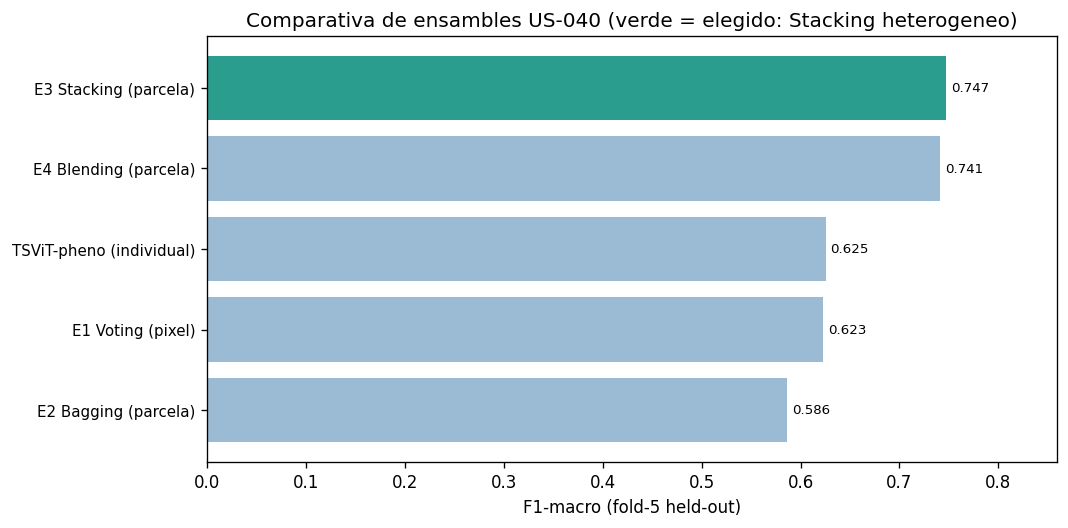

In [3]:
import polars as pl

# Tabla real de US-040 (fold-5 held-out): los 4 ensambles + el mejor individual.
cmp_csv = REPO / 'reports/ensemble/metrics/comparison_us040.csv'
if cmp_csv.is_file():
    df = pl.read_csv(cmp_csv, infer_schema_length=None).sort('f1_macro', descending=True)
    show = df.with_columns([
        pl.col('f1_macro').round(4),
        pl.col('accuracy').round(4),
        pl.col('inference_time_s').round(3),
    ])
    display(show)
else:
    display(Markdown('> Tabla no encontrada (se genera en US-040).'))

show_saved_png(FIG_DIR / MANIFEST['ensemble']['figure'],
               caption='Comparativa de ensambles (verde = elegido: Stacking).')

**Como leer la tabla (interpretacion honesta):**

- **Stacking (0.747)** es el mejor: el meta-modelo aprendido exprime la heterogeneidad denso+tabular mejor que cualquier regla fija. Es el **elegido**.
- **Blending (0.741)** queda a un pelo (-0.6 pts) y es **~7x mas rapido** en inferencia (pesos fijos vs meta-modelo). Si la latencia fuera critica, seria un cambio razonable por casi el mismo F1.
- **TSViT-pheno individual (0.625)**: el mejor modelo solo. Los dos ensambles ganadores le sacan **+12 pts** -- esa es la ganancia real de ensamblar.
- **Voting (0.622)**: promediar a ciegas casi no mejora sobre el mejor individual y ademas es lentisimo (opera por pixel en todo el patch: ~42 s). El promedio uniforme arrastra a los miembros debiles.
- **Bagging (0.586)**: el peor. Re-muestrear un solo tipo de modelo (XGBoost-AlphaEarth) no aporta diversidad real -- todos los bags cometen el mismo sesgo. Confirma que **la diversidad importa mas que la cantidad**.

Conclusion de US-040: **gana la heterogeneidad aprendida** (Stacking), no el volumen ni el promedio simple.

## El modelo en accion: inferencias del Stacking parcela a parcela

Las metricas y las curvas resumen el rendimiento, pero no muestran al modelo *trabajando* sobre el terreno. Aqui se ve, sobre patches reales del **fold-5 held-out** (escenas con 8-9 cultivos distintos, no monocultivos) (que el modelo NO vio al entrenar), las cuatro piezas que entran y salen del ensamble, alineadas parcela a parcela:

1. **La fuente de la verdad**: la imagen RGB real del patch (lo que captura el satelite) y la **verdad de campo** (cada parcela con su cultivo real, de los poligonos de PASTIS).
2. **Lo predicho**: la clase que el **Stacking** asigna a cada parcela, con su etiqueta -- comparable visualmente contra la verdad.
3. **La fenologia**: la curva NDVI temporal de cada parcela (como cambia su verdor a lo largo del ano) y una descripcion derivada de ella -- es la senal que los miembros temporales (TSViT, U-TAE) explotan.
4. **El embedding**: el miembro tabular (XGBoost) consume el vector **AlphaEarth de 64 dimensiones** por parcela -- un resumen aprendido del Foundation Model que condensa la firma espectro-temporal anual.

La prediccion del Stacking se reconstruye desde las **OOF reales** de sus tres base learners (promedio post-softmax por parcela). El titulo de cada figura dice cuantas parcelas acerto.

2026-06-12 11:02:39 [info     ] ensemble_inference_card        ensemble='Stacking (campeon)' figure=C:\Users\arthu\Proyectos\MNA\agro_sat_copilot\reports\ensemble\figures\inference\inference_stacking--campeon_40039.png n_correct=60 n_parcels=73 patch_id=40039


2026-06-12 11:02:40 [info     ] ensemble_inference_card        ensemble='Stacking (campeon)' figure=C:\Users\arthu\Proyectos\MNA\agro_sat_copilot\reports\ensemble\figures\inference\inference_stacking--campeon_40005.png n_correct=87 n_parcels=114 patch_id=40005


2026-06-12 11:02:40 [info     ] ensemble_inference_card        ensemble='Stacking (campeon)' figure=C:\Users\arthu\Proyectos\MNA\agro_sat_copilot\reports\ensemble\figures\inference\inference_stacking--campeon_40175.png n_correct=68 n_parcels=76 patch_id=40175


### Patch 40039: el Stacking acerto **60 de 73** parcelas (82%). Embedding tabular: AlphaEarth 64-dim por parcela.

**Izq: RGB real (fuente de la verdad). Centro: verdad de campo por parcela. Der: prediccion del Stacking por parcela. (La descripcion fenologica va aparte, debajo, no sobre la imagen.)**

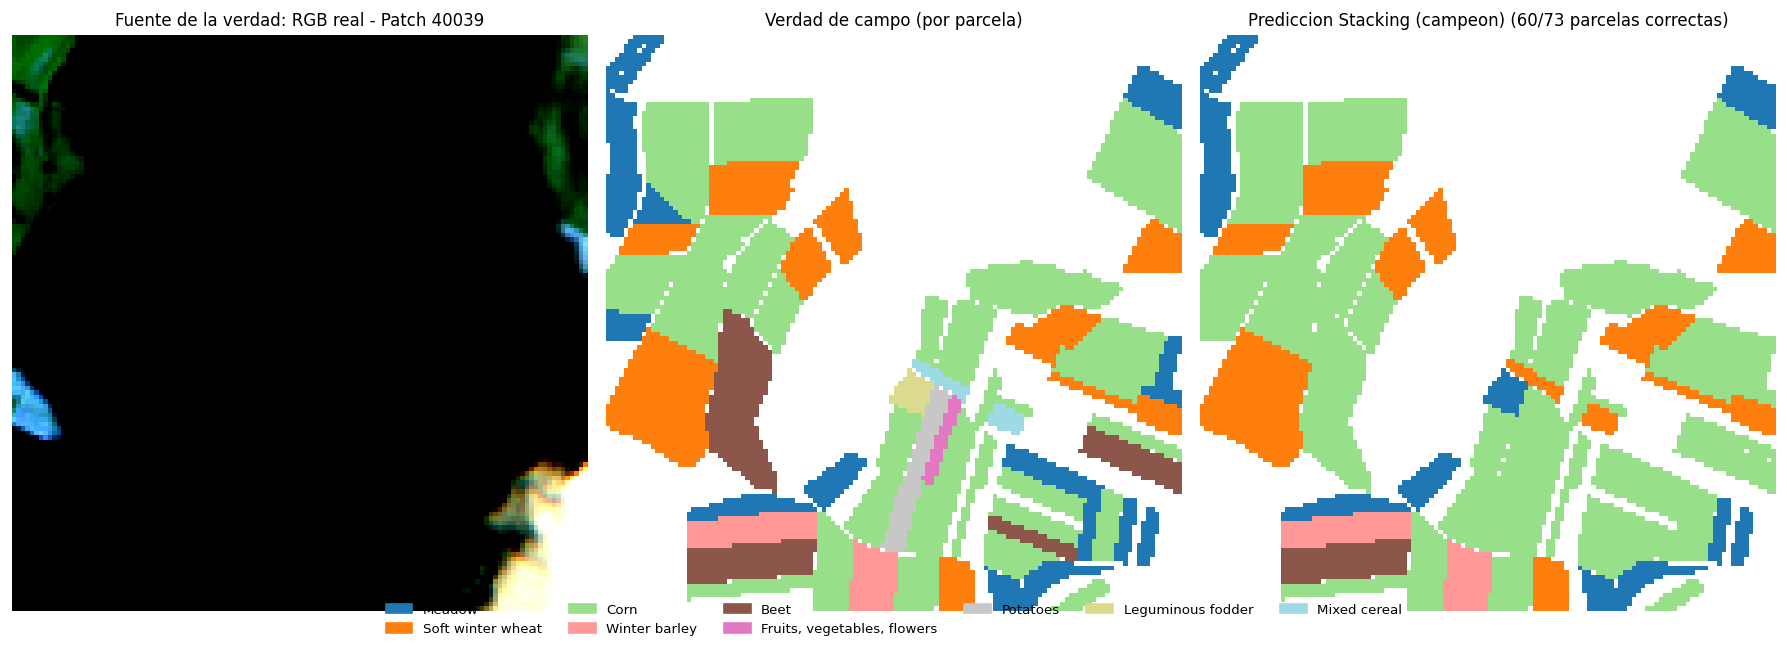

**Fenologia que apoya cada prediccion** (curva NDVI por parcela, fuera de la imagen):

- **40039_7223563** -> predice **Corn** (real: Beet, error, pico NDVI 1.0): pico de vigor alto (NDVI 1.00) tardio; dinamica estacional marcada (amplitud 1.01)
- **40039_7260261** -> predice **Corn** (real: Corn, acierto, pico NDVI 0.99): pico de vigor alto (NDVI 0.99) tardio; dinamica estacional marcada (amplitud 0.98)
- **40039_7281691** -> predice **Corn** (real: Corn, acierto, pico NDVI 0.999): pico de vigor alto (NDVI 1.00) tardio; dinamica estacional marcada (amplitud 0.99)
- **40039_15903124** -> predice **Soft winter wheat** (real: Soft winter wheat, acierto, pico NDVI 0.99): pico de vigor alto (NDVI 0.99) a media temporada; dinamica estacional marcada (amplitud 1.00)
- **40039_15895405** -> predice **Beet** (real: Beet, acierto, pico NDVI 1.0): pico de vigor alto (NDVI 1.00) tardio; dinamica estacional marcada (amplitud 1.00)
- **40039_10979882** -> predice **Corn** (real: Corn, acierto, pico NDVI 1.0): pico de vigor alto (NDVI 1.00) tardio; dinamica estacional marcada (amplitud 0.98)

parcela,clase_real,clase_predicha,acierto,area_px,ndvi_pico,fenologia
str,str,str,bool,i64,f64,str
"""40039_7223563""","""Beet""","""Corn""",false,403,1.0,"""pico de vigor alto (NDVI 1.00)…"
"""40039_7260261""","""Corn""","""Corn""",true,385,0.99,"""pico de vigor alto (NDVI 0.99)…"
"""40039_7281691""","""Corn""","""Corn""",true,336,0.999,"""pico de vigor alto (NDVI 1.00)…"
"""40039_15903124""","""Soft winter wheat""","""Soft winter wheat""",true,284,0.99,"""pico de vigor alto (NDVI 0.99)…"
"""40039_15895405""","""Beet""","""Beet""",true,225,1.0,"""pico de vigor alto (NDVI 1.00)…"
"""40039_10979882""","""Corn""","""Corn""",true,222,1.0,"""pico de vigor alto (NDVI 1.00)…"
"""40039_7334722""","""Soft winter wheat""","""Soft winter wheat""",true,211,1.0,"""pico de vigor alto (NDVI 1.00)…"
"""40039_7321424""","""Corn""","""Corn""",true,203,1.0,"""pico de vigor alto (NDVI 1.00)…"
"""40039_7281567""","""Meadow""","""Meadow""",true,198,1.0,"""pico de vigor alto (NDVI 1.00)…"


### Patch 40005: el Stacking acerto **87 de 114** parcelas (76%). Embedding tabular: AlphaEarth 64-dim por parcela.

**Izq: RGB real (fuente de la verdad). Centro: verdad de campo por parcela. Der: prediccion del Stacking por parcela. (La descripcion fenologica va aparte, debajo, no sobre la imagen.)**

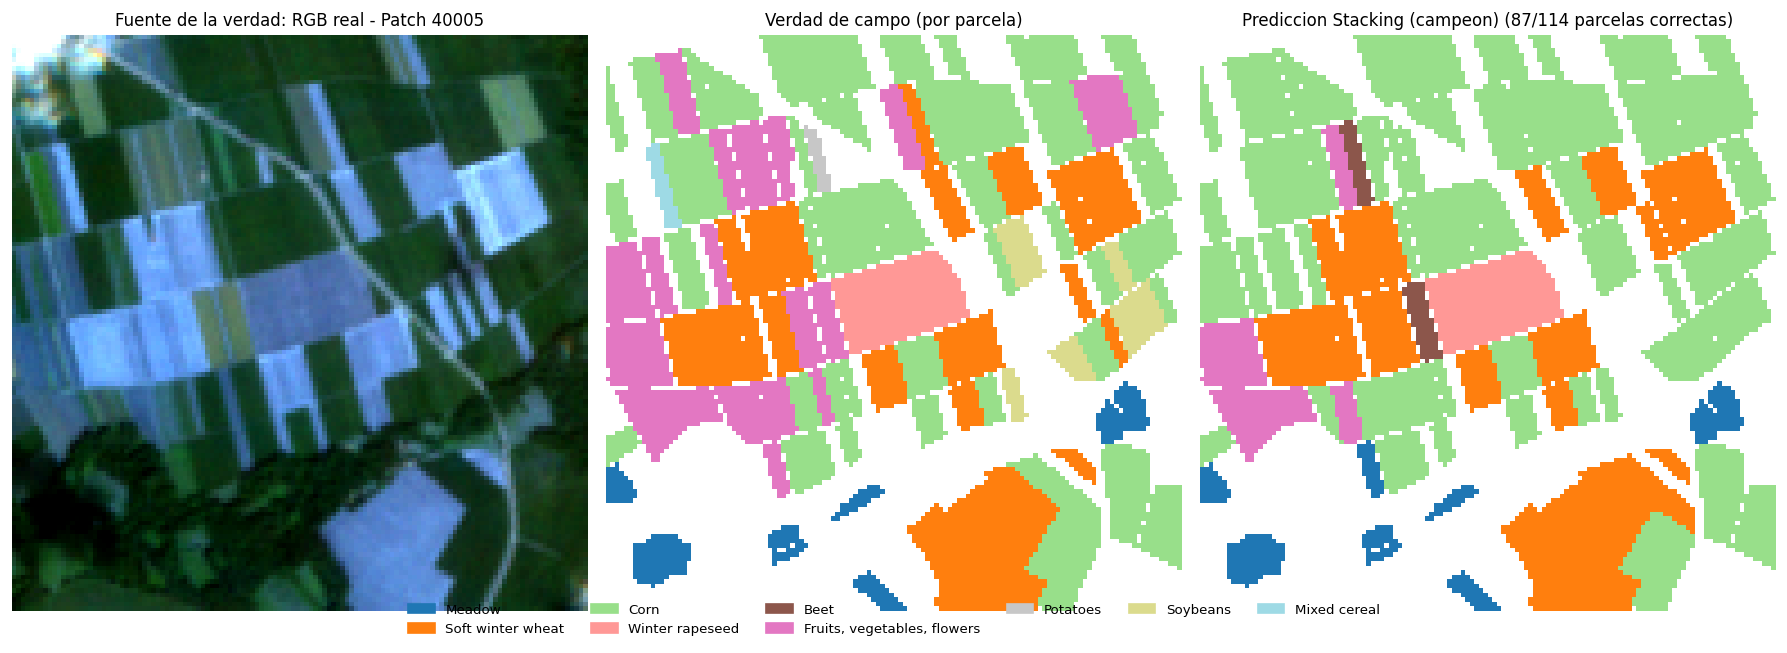

**Fenologia que apoya cada prediccion** (curva NDVI por parcela, fuera de la imagen):

- **40005_7333413** -> predice **Soft winter wheat** (real: Soft winter wheat, acierto, pico NDVI 0.942): pico de vigor alto (NDVI 0.94) a media temporada; dinamica estacional marcada (amplitud 0.94)
- **40005_7330237** -> predice **Corn** (real: Corn, acierto, pico NDVI 1.184): pico de vigor alto (NDVI 1.18) tardio; dinamica estacional marcada (amplitud 1.24)
- **40005_10988418** -> predice **Corn** (real: Corn, acierto, pico NDVI 0.917): pico de vigor alto (NDVI 0.92) tardio; dinamica estacional marcada (amplitud 0.97)
- **40005_10989047** -> predice **Corn** (real: Corn, acierto, pico NDVI 1.0): pico de vigor alto (NDVI 1.00) tardio; dinamica estacional marcada (amplitud 1.03)
- **40005_7310842** -> predice **Soft winter wheat** (real: Soft winter wheat, acierto, pico NDVI 0.904): pico de vigor alto (NDVI 0.90) a media temporada; dinamica estacional marcada (amplitud 0.95)
- **40005_7333651** -> predice **Corn** (real: Corn, acierto, pico NDVI 0.865): pico de vigor alto (NDVI 0.86) tardio; dinamica estacional marcada (amplitud 0.86)

parcela,clase_real,clase_predicha,acierto,area_px,ndvi_pico,fenologia
str,str,str,bool,i64,f64,str
"""40005_7333413""","""Soft winter wheat""","""Soft winter wheat""",true,709,0.942,"""pico de vigor alto (NDVI 0.94)…"
"""40005_7330237""","""Corn""","""Corn""",true,227,1.184,"""pico de vigor alto (NDVI 1.18)…"
"""40005_10988418""","""Corn""","""Corn""",true,216,0.917,"""pico de vigor alto (NDVI 0.92)…"
"""40005_10989047""","""Corn""","""Corn""",true,211,1.0,"""pico de vigor alto (NDVI 1.00)…"
"""40005_7310842""","""Soft winter wheat""","""Soft winter wheat""",true,200,0.904,"""pico de vigor alto (NDVI 0.90)…"
"""40005_7333651""","""Corn""","""Corn""",true,193,0.865,"""pico de vigor alto (NDVI 0.86)…"
"""40005_13361589""","""Fruits, vegetables, flowers""","""Fruits, vegetables, flowers""",true,193,1.0,"""pico de vigor alto (NDVI 1.00)…"
"""40005_10990238""","""Winter rapeseed""","""Winter rapeseed""",true,190,0.853,"""pico de vigor alto (NDVI 0.85)…"
"""40005_15908176""","""Corn""","""Corn""",true,190,0.921,"""pico de vigor alto (NDVI 0.92)…"


### Patch 40175: el Stacking acerto **68 de 76** parcelas (89%). Embedding tabular: AlphaEarth 64-dim por parcela.

**Izq: RGB real (fuente de la verdad). Centro: verdad de campo por parcela. Der: prediccion del Stacking por parcela. (La descripcion fenologica va aparte, debajo, no sobre la imagen.)**

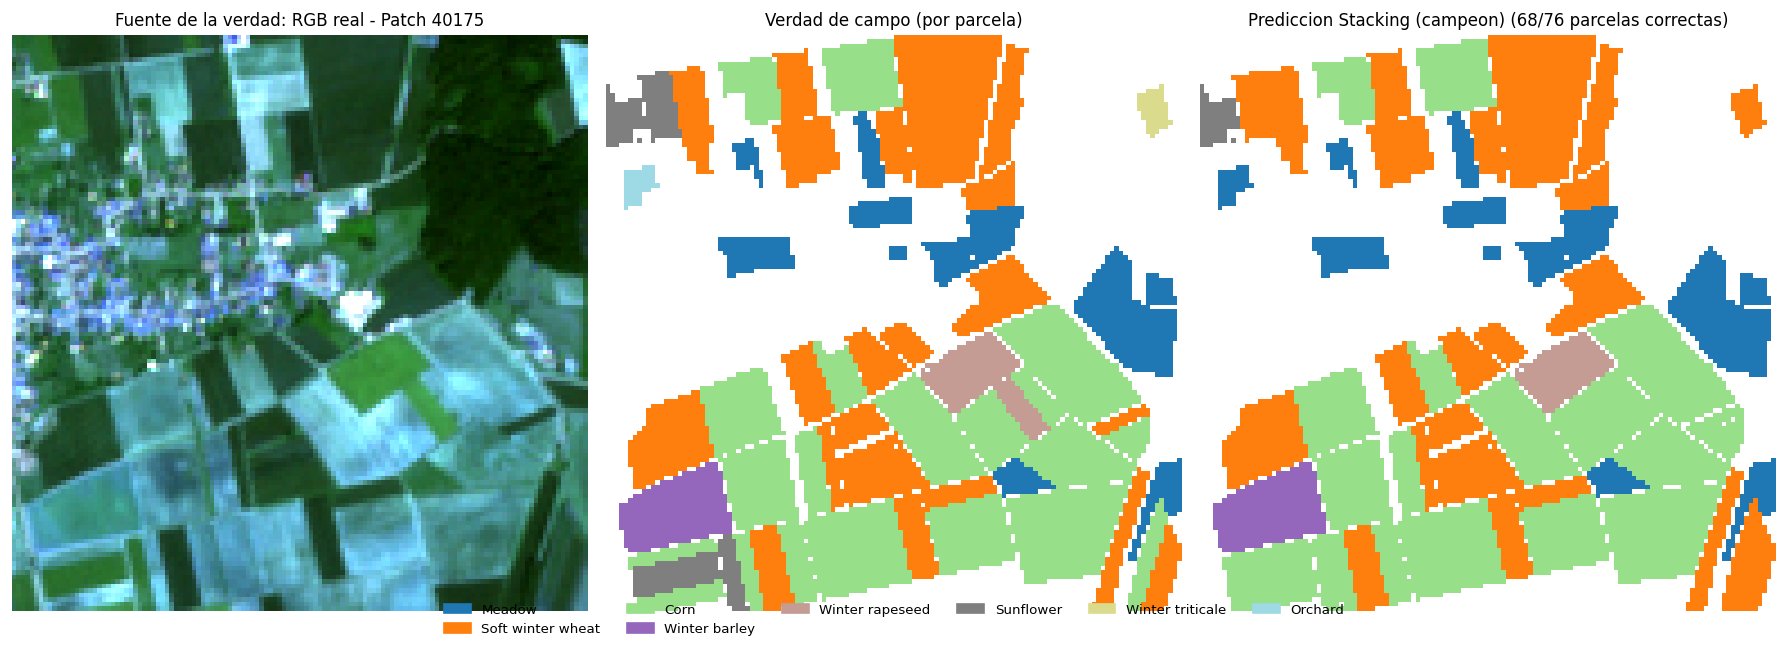

**Fenologia que apoya cada prediccion** (curva NDVI por parcela, fuera de la imagen):

- **40175_7235574** -> predice **Meadow** (real: Meadow, acierto, pico NDVI 0.786): pico de vigor alto (NDVI 0.79) a media temporada; dinamica estacional marcada (amplitud 0.80)
- **40175_7234054** -> predice **Winter barley** (real: Winter barley, acierto, pico NDVI 0.92): pico de vigor alto (NDVI 0.92) a media temporada; dinamica estacional marcada (amplitud 0.95)
- **40175_7275069** -> predice **Corn** (real: Corn, acierto, pico NDVI 0.915): pico de vigor alto (NDVI 0.91) tardio; dinamica estacional marcada (amplitud 0.94)
- **40175_7235571** -> predice **Corn** (real: Corn, acierto, pico NDVI 0.86): pico de vigor alto (NDVI 0.86) tardio; dinamica estacional marcada (amplitud 0.90)
- **40175_15901758** -> predice **Soft winter wheat** (real: Soft winter wheat, acierto, pico NDVI 1.803): pico de vigor alto (NDVI 1.80) tardio; dinamica estacional marcada (amplitud 1.80)
- **40175_15893644** -> predice **Corn** (real: Corn, acierto, pico NDVI 0.914): pico de vigor alto (NDVI 0.91) tardio; dinamica estacional marcada (amplitud 0.94)

parcela,clase_real,clase_predicha,acierto,area_px,ndvi_pico,fenologia
str,str,str,bool,i64,f64,str
"""40175_7235574""","""Meadow""","""Meadow""",true,357,0.786,"""pico de vigor alto (NDVI 0.79)…"
"""40175_7234054""","""Winter barley""","""Winter barley""",true,340,0.92,"""pico de vigor alto (NDVI 0.92)…"
"""40175_7275069""","""Corn""","""Corn""",true,325,0.915,"""pico de vigor alto (NDVI 0.91)…"
"""40175_7235571""","""Corn""","""Corn""",true,299,0.86,"""pico de vigor alto (NDVI 0.86)…"
"""40175_15901758""","""Soft winter wheat""","""Soft winter wheat""",true,297,1.803,"""pico de vigor alto (NDVI 1.80)…"
"""40175_15893644""","""Corn""","""Corn""",true,276,0.914,"""pico de vigor alto (NDVI 0.91)…"
"""40175_15910755""","""Soft winter wheat""","""Soft winter wheat""",true,273,0.899,"""pico de vigor alto (NDVI 0.90)…"
"""40175_7316609""","""Corn""","""Corn""",true,257,0.87,"""pico de vigor alto (NDVI 0.87)…"
"""40175_15906043""","""Corn""","""Corn""",true,249,0.89,"""pico de vigor alto (NDVI 0.89)…"


In [4]:
from pathlib import Path
import polars as pl
from ml.report.ensemble_inference_cards import build_stacking_inference_cards

pastis_root = REPO / 'data/PASTIS-R'
patches = ['40039', '40005', '40175']  # escenas con 8-9 cultivos distintos (no monocultivo)


def _fenologia_markdown(card, top=6):
    """Render the phenology that SUPPORTS each prediction as text (NOT on the image)."""
    rows = card.table.sort('area_px', descending=True).head(top)
    lines = ['**Fenologia que apoya cada prediccion** (curva NDVI por parcela, fuera de la imagen):', '']
    for r in rows.iter_rows(named=True):
        ok = 'acierto' if r['acierto'] else 'error'
        lines.append(
            f"- **{r['parcela']}** -> predice **{r['clase_predicha']}** "
            f"(real: {r['clase_real']}, {ok}, pico NDVI {r['ndvi_pico']}): {r['fenologia']}"
        )
    return Markdown(chr(10).join(lines))


if pastis_root.exists():
    cards = build_stacking_inference_cards(
        patches,
        pastis_root=pastis_root,
        oof_dir=REPO / 'ml/eval/oof',
        features_path=REPO / 'data/features/features_fused_pastis.parquet',
        out_dir=REPO / 'reports/ensemble/figures/inference',
        members=('tsvit-pheno', 'utae', 'xgb-alphaearth'),
        ensemble_label='Stacking (campeon)',
    )
    for card in cards:
        acc = 100 * card.n_correct / max(card.n_parcels, 1)
        display(Markdown(
            f'### Patch {card.patch_id}: el Stacking acerto '
            f'**{card.n_correct} de {card.n_parcels}** parcelas '
            f'({acc:.0f}%). Embedding tabular: AlphaEarth '
            f'{card.n_alphaearth_dims}-dim por parcela.'))
        show_saved_png(card.figure_path,
            caption='Izq: RGB real (fuente de la verdad). '
                    'Centro: verdad de campo por parcela. '
                    'Der: prediccion del Stacking por parcela. '
                    '(La descripcion fenologica va aparte, debajo, no sobre la imagen.)')
        # La fenologia que apoya cada prediccion, como TEXTO via display (no sobre la imagen).
        display(_fenologia_markdown(card))
        # Tabla completa por parcela (verdad, prediccion, acierto, NDVI, fenologia).
        display(card.table.select(
            ['parcela', 'clase_real', 'clase_predicha', 'acierto',
             'area_px', 'ndvi_pico', 'fenologia']).head(10))
else:
    display(Markdown('> PASTIS-R no presente: las fichas se generan al '
        're-ejecutar donde este el dataset (VM o local con DVC).'))


**Como leer estas fichas (lo que revelan que las metricas no):**

- **Donde acierta**: la mayoria de las parcelas conservan su color entre el panel central (verdad) y el derecho (prediccion) -- el Stacking reproduce el mosaico agricola real, no solo la clase dominante.
- **Donde falla**: las parcelas que cambian de color son los errores. Tipicamente son **parcelas pequenas** o de **clases raras** que se confunden con su vecino dominante o con un cultivo de fenologia parecida -- exactamente el patron que la matriz de confusion y la curva PR ya anticipaban.
- **El papel de la fenologia**: en la tabla, las parcelas bien resueltas suelen tener una curva NDVI con un pico claro (dinamica marcada); las ambiguas tienen curvas planas o picos debiles, donde hasta el ensamble duda. Esto conecta la decision del modelo con una senal agronomica interpretable, no con una caja negra.

En conjunto, las fichas hacen tangible por que el ensamble heterogeneo funciona: combina la **forma temporal** (NDVI, que ven TSViT/U-TAE) con el **resumen espectral aprendido** (AlphaEarth, que ve XGBoost), y el meta-modelo decide a quien creerle en cada parcela.

### Los ensambles que NO ganaron: tambien sus predicciones (con la fenologia que las apoya)

No solo el campeon merece verse en accion. Aqui las mismas fichas parcela a parcela para **dos ensambles que NO ganaron**, con su **prediccion real** (no el consenso): el **Blending-3** (0.744, el subcampeon, mezcla convexa Optuna) y el **Stacking-5/fullm** (0.648, el que usa el "mejor TSViT individual" pero apila peor). Se eligen **escenas diversas (8-9 cultivos distintos por patch)**, no monocultivos, para que el contraste sea exigente. Asi se ve *donde* fallan distinto al ganador. La descripcion fenologica que apoya cada prediccion va, como en el campeon, **con un display de texto debajo de la imagen -- nunca sobre ella**.

2026-06-12 11:02:43 [info     ] parcel_ground_truth_built      n_parcels=16640 n_patches=496


2026-06-12 11:02:45 [info     ] parcel_geometries_built        n_parcels=28532


2026-06-12 11:02:46 [debug    ] oof_member_loaded              member=tsvit-pheno n_rows=28532 path=C:\Users\arthu\Proyectos\MNA\agro_sat_copilot\ml\eval\oof\oof_parcel_tsvit-pheno_fold5.parquet space=parcel


2026-06-12 11:02:46 [debug    ] oof_member_loaded              member=utae n_rows=28532 path=C:\Users\arthu\Proyectos\MNA\agro_sat_copilot\ml\eval\oof\oof_parcel_utae_fold5.parquet space=parcel


2026-06-12 11:02:46 [debug    ] oof_member_loaded              member=xgb-alphaearth n_rows=16640 path=C:\Users\arthu\Proyectos\MNA\agro_sat_copilot\ml\eval\oof\oof_parcel_xgb-alphaearth_fold5.parquet space=parcel


...

2026-06-12 11:02:55 [info     ] ensemble_inference_card        ensemble='Blending-3 (subcampeon)' figure=C:\Users\arthu\Proyectos\MNA\agro_sat_copilot\reports\ensemble\figures\inference\inference_blending-3--subcampeon_40039.png n_correct=65 n_parcels=73 patch_id=40039


2026-06-12 11:02:55 [info     ] ensemble_inference_card        ensemble='Blending-3 (subcampeon)' figure=C:\Users\arthu\Proyectos\MNA\agro_sat_copilot\reports\ensemble\figures\inference\inference_blending-3--subcampeon_40005.png n_correct=97 n_parcels=114 patch_id=40005


2026-06-12 11:02:56 [info     ] ensemble_inference_card        ensemble='Blending-3 (subcampeon)' figure=C:\Users\arthu\Proyectos\MNA\agro_sat_copilot\reports\ensemble\figures\inference\inference_blending-3--subcampeon_40175.png n_correct=71 n_parcels=76 patch_id=40175


#### Blending-3 (subcampeon) -- Patch 40039: **65/73** parcelas correctas (89%)

**Blending-3 (subcampeon): izq RGB real | centro verdad | der prediccion. La fenologia va como texto debajo, no sobre la imagen.**

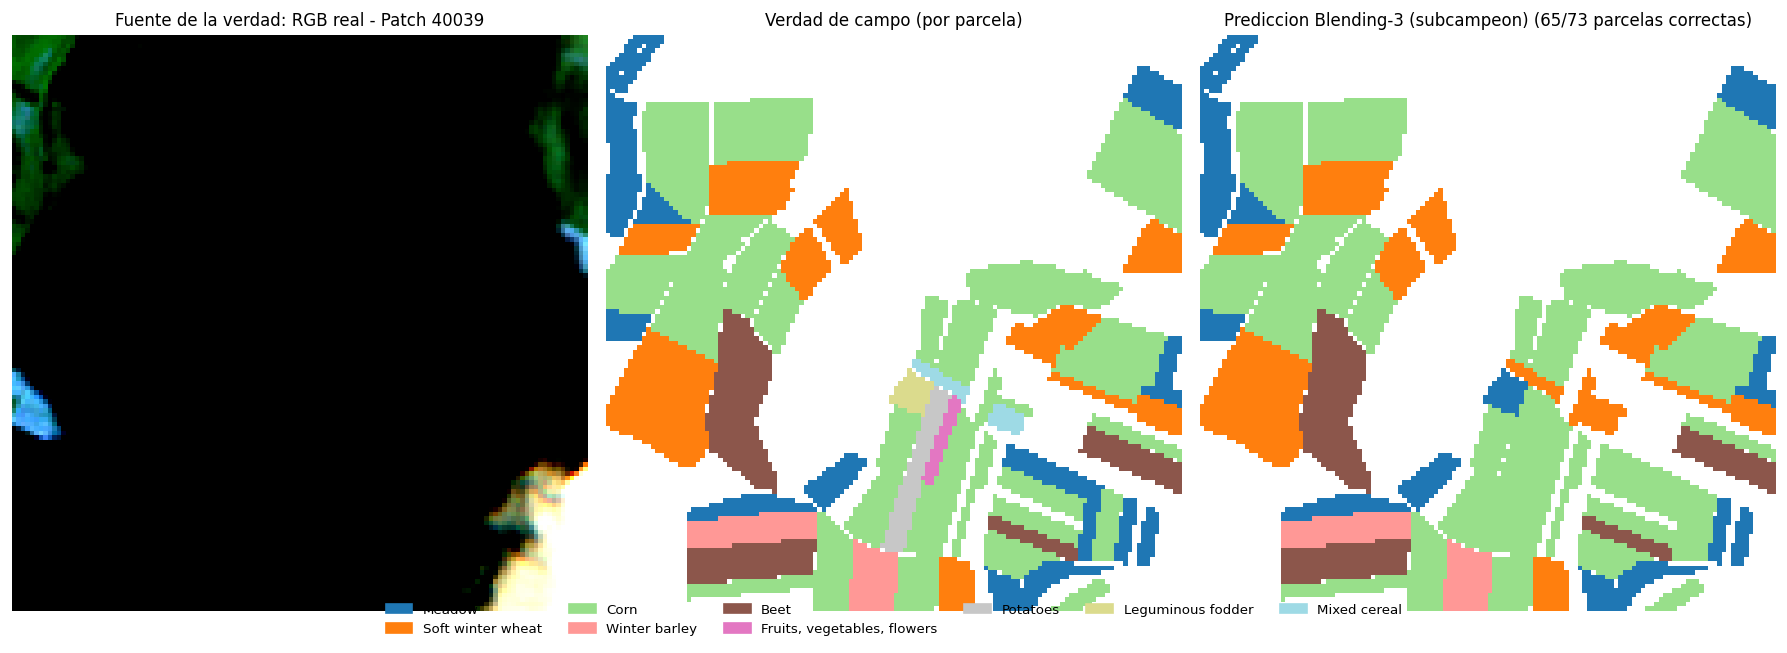

**Fenologia que apoya cada prediccion** (curva NDVI por parcela, fuera de la imagen):

- **40039_7223563** -> predice **Beet** (real: Beet, acierto, pico NDVI 1.0): pico de vigor alto (NDVI 1.00) tardio; dinamica estacional marcada (amplitud 1.01)
- **40039_7260261** -> predice **Corn** (real: Corn, acierto, pico NDVI 0.99): pico de vigor alto (NDVI 0.99) tardio; dinamica estacional marcada (amplitud 0.98)
- **40039_7281691** -> predice **Corn** (real: Corn, acierto, pico NDVI 0.999): pico de vigor alto (NDVI 1.00) tardio; dinamica estacional marcada (amplitud 0.99)
- **40039_15903124** -> predice **Soft winter wheat** (real: Soft winter wheat, acierto, pico NDVI 0.99): pico de vigor alto (NDVI 0.99) a media temporada; dinamica estacional marcada (amplitud 1.00)
- **40039_15895405** -> predice **Beet** (real: Beet, acierto, pico NDVI 1.0): pico de vigor alto (NDVI 1.00) tardio; dinamica estacional marcada (amplitud 1.00)
- **40039_10979882** -> predice **Corn** (real: Corn, acierto, pico NDVI 1.0): pico de vigor alto (NDVI 1.00) tardio; dinamica estacional marcada (amplitud 0.98)

#### Blending-3 (subcampeon) -- Patch 40005: **97/114** parcelas correctas (85%)

**Blending-3 (subcampeon): izq RGB real | centro verdad | der prediccion. La fenologia va como texto debajo, no sobre la imagen.**

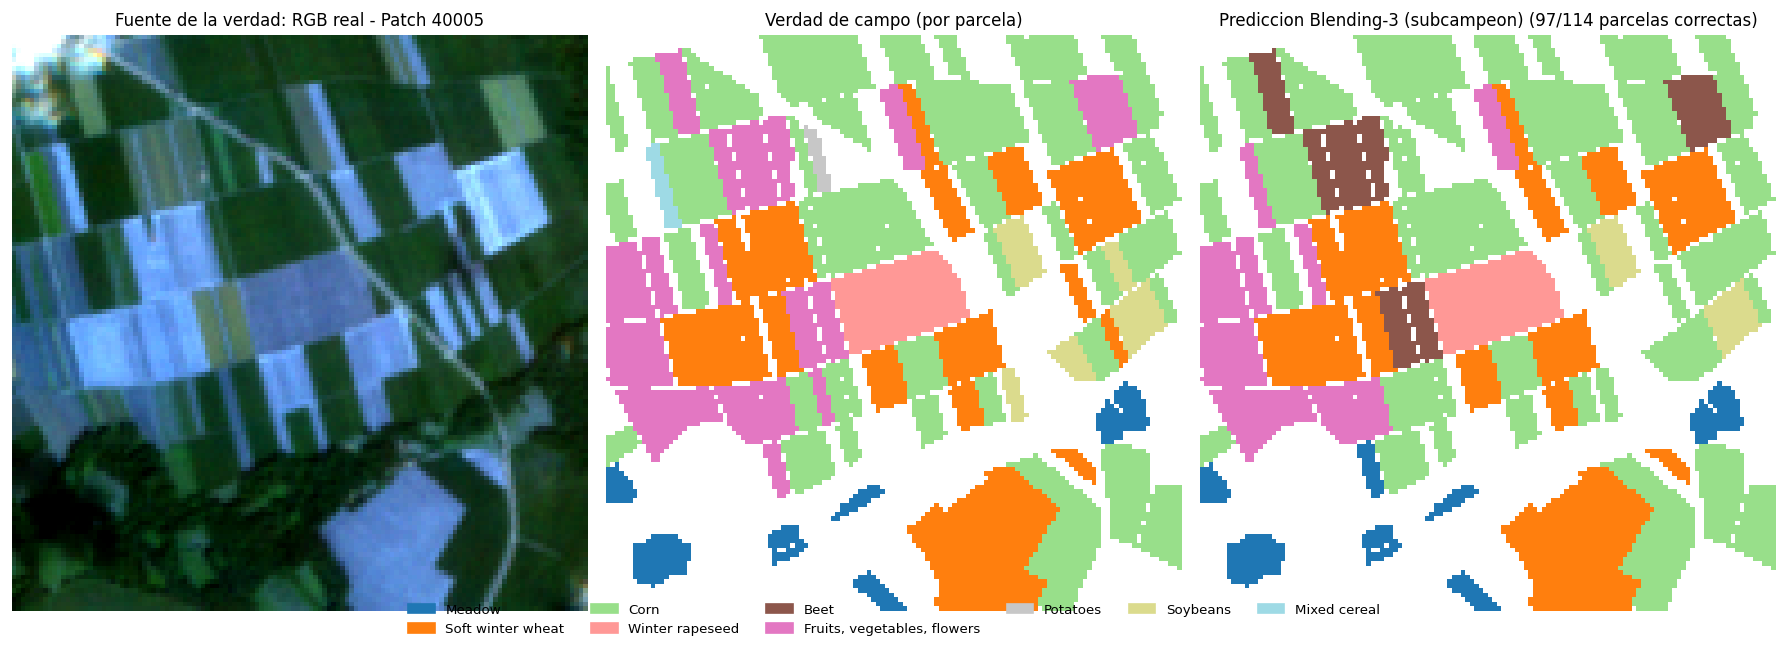

**Fenologia que apoya cada prediccion** (curva NDVI por parcela, fuera de la imagen):

- **40005_7333413** -> predice **Soft winter wheat** (real: Soft winter wheat, acierto, pico NDVI 0.942): pico de vigor alto (NDVI 0.94) a media temporada; dinamica estacional marcada (amplitud 0.94)
- **40005_7330237** -> predice **Corn** (real: Corn, acierto, pico NDVI 1.184): pico de vigor alto (NDVI 1.18) tardio; dinamica estacional marcada (amplitud 1.24)
- **40005_10988418** -> predice **Corn** (real: Corn, acierto, pico NDVI 0.917): pico de vigor alto (NDVI 0.92) tardio; dinamica estacional marcada (amplitud 0.97)
- **40005_10989047** -> predice **Corn** (real: Corn, acierto, pico NDVI 1.0): pico de vigor alto (NDVI 1.00) tardio; dinamica estacional marcada (amplitud 1.03)
- **40005_7310842** -> predice **Soft winter wheat** (real: Soft winter wheat, acierto, pico NDVI 0.904): pico de vigor alto (NDVI 0.90) a media temporada; dinamica estacional marcada (amplitud 0.95)
- **40005_7333651** -> predice **Corn** (real: Corn, acierto, pico NDVI 0.865): pico de vigor alto (NDVI 0.86) tardio; dinamica estacional marcada (amplitud 0.86)

#### Blending-3 (subcampeon) -- Patch 40175: **71/76** parcelas correctas (93%)

**Blending-3 (subcampeon): izq RGB real | centro verdad | der prediccion. La fenologia va como texto debajo, no sobre la imagen.**

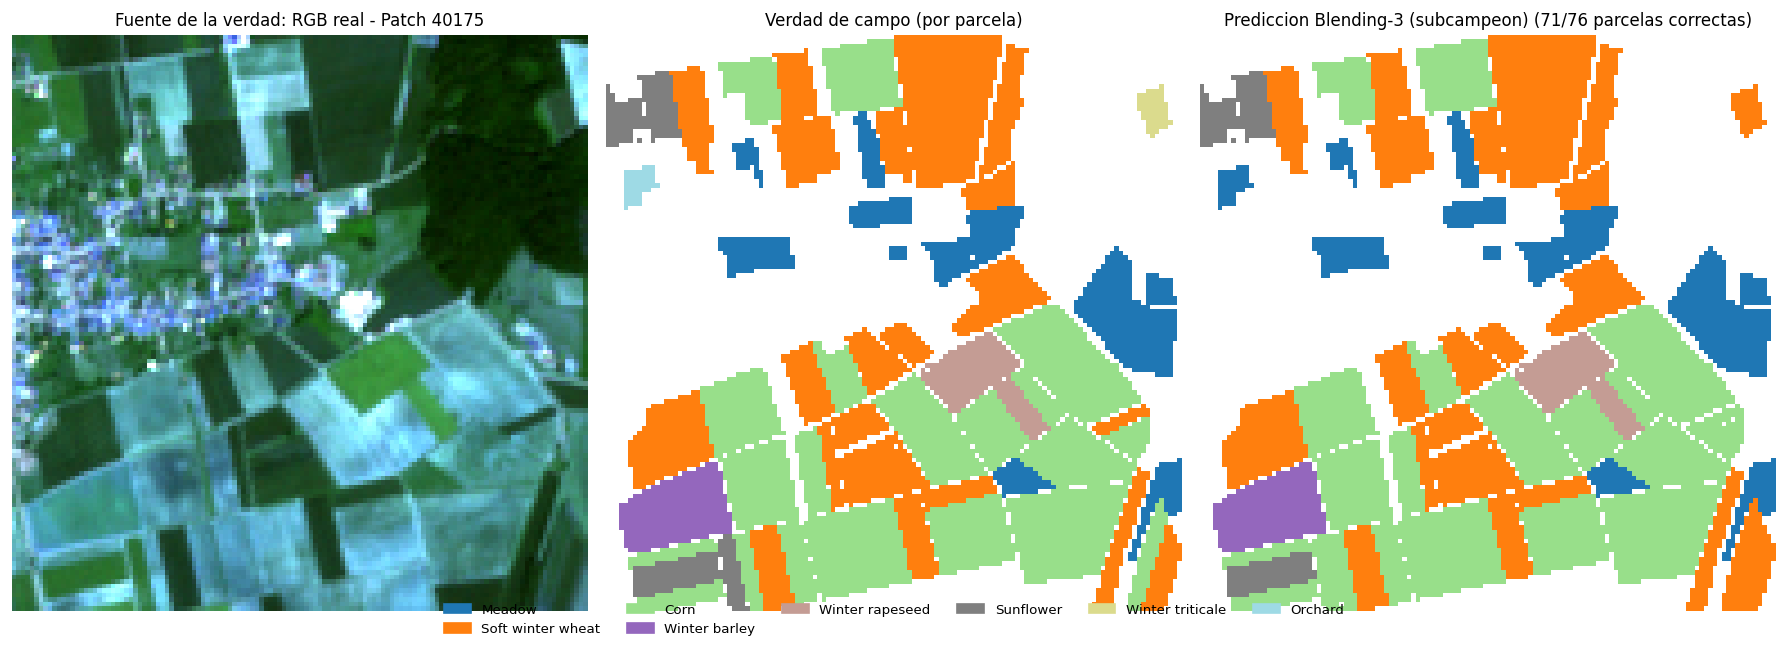

**Fenologia que apoya cada prediccion** (curva NDVI por parcela, fuera de la imagen):

- **40175_7235574** -> predice **Meadow** (real: Meadow, acierto, pico NDVI 0.786): pico de vigor alto (NDVI 0.79) a media temporada; dinamica estacional marcada (amplitud 0.80)
- **40175_7234054** -> predice **Winter barley** (real: Winter barley, acierto, pico NDVI 0.92): pico de vigor alto (NDVI 0.92) a media temporada; dinamica estacional marcada (amplitud 0.95)
- **40175_7275069** -> predice **Corn** (real: Corn, acierto, pico NDVI 0.915): pico de vigor alto (NDVI 0.91) tardio; dinamica estacional marcada (amplitud 0.94)
- **40175_7235571** -> predice **Corn** (real: Corn, acierto, pico NDVI 0.86): pico de vigor alto (NDVI 0.86) tardio; dinamica estacional marcada (amplitud 0.90)
- **40175_15901758** -> predice **Soft winter wheat** (real: Soft winter wheat, acierto, pico NDVI 1.803): pico de vigor alto (NDVI 1.80) tardio; dinamica estacional marcada (amplitud 1.80)
- **40175_15893644** -> predice **Corn** (real: Corn, acierto, pico NDVI 0.914): pico de vigor alto (NDVI 0.91) tardio; dinamica estacional marcada (amplitud 0.94)

2026-06-12 11:02:56 [info     ] ensemble_inference_card        ensemble=Stacking-5/fullm figure=C:\Users\arthu\Proyectos\MNA\agro_sat_copilot\reports\ensemble\figures\inference\inference_stacking-5-fullm_40039.png n_correct=57 n_parcels=73 patch_id=40039


2026-06-12 11:02:56 [info     ] ensemble_inference_card        ensemble=Stacking-5/fullm figure=C:\Users\arthu\Proyectos\MNA\agro_sat_copilot\reports\ensemble\figures\inference\inference_stacking-5-fullm_40005.png n_correct=91 n_parcels=114 patch_id=40005


2026-06-12 11:02:57 [info     ] ensemble_inference_card        ensemble=Stacking-5/fullm figure=C:\Users\arthu\Proyectos\MNA\agro_sat_copilot\reports\ensemble\figures\inference\inference_stacking-5-fullm_40175.png n_correct=61 n_parcels=76 patch_id=40175


#### Stacking-5/fullm -- Patch 40039: **57/73** parcelas correctas (78%)

**Stacking-5/fullm: izq RGB real | centro verdad | der prediccion. La fenologia va como texto debajo, no sobre la imagen.**

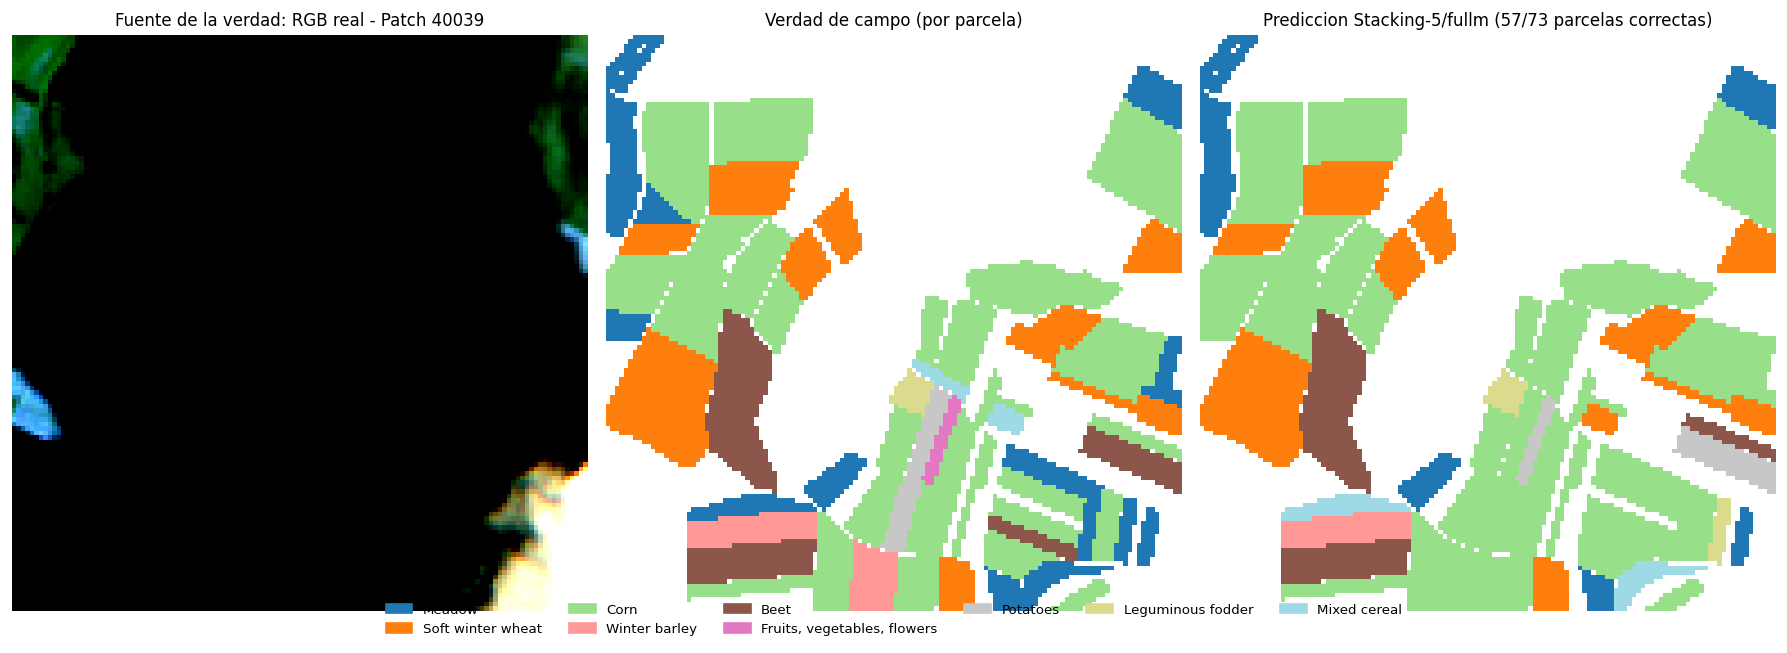

**Fenologia que apoya cada prediccion** (curva NDVI por parcela, fuera de la imagen):

- **40039_7223563** -> predice **Beet** (real: Beet, acierto, pico NDVI 1.0): pico de vigor alto (NDVI 1.00) tardio; dinamica estacional marcada (amplitud 1.01)
- **40039_7260261** -> predice **Corn** (real: Corn, acierto, pico NDVI 0.99): pico de vigor alto (NDVI 0.99) tardio; dinamica estacional marcada (amplitud 0.98)
- **40039_7281691** -> predice **Corn** (real: Corn, acierto, pico NDVI 0.999): pico de vigor alto (NDVI 1.00) tardio; dinamica estacional marcada (amplitud 0.99)
- **40039_15903124** -> predice **Soft winter wheat** (real: Soft winter wheat, acierto, pico NDVI 0.99): pico de vigor alto (NDVI 0.99) a media temporada; dinamica estacional marcada (amplitud 1.00)
- **40039_15895405** -> predice **Beet** (real: Beet, acierto, pico NDVI 1.0): pico de vigor alto (NDVI 1.00) tardio; dinamica estacional marcada (amplitud 1.00)
- **40039_10979882** -> predice **Corn** (real: Corn, acierto, pico NDVI 1.0): pico de vigor alto (NDVI 1.00) tardio; dinamica estacional marcada (amplitud 0.98)

#### Stacking-5/fullm -- Patch 40005: **91/114** parcelas correctas (80%)

**Stacking-5/fullm: izq RGB real | centro verdad | der prediccion. La fenologia va como texto debajo, no sobre la imagen.**

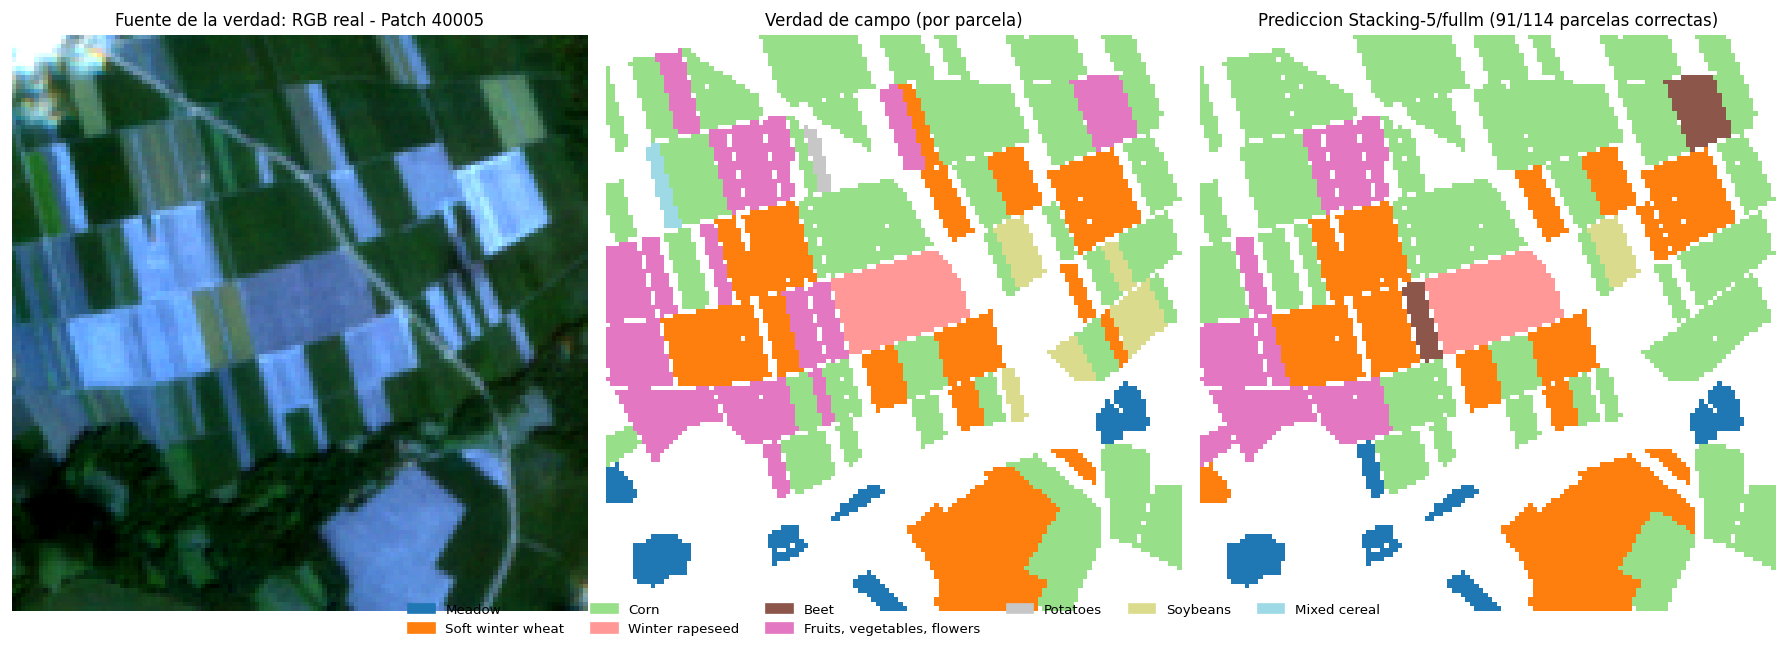

**Fenologia que apoya cada prediccion** (curva NDVI por parcela, fuera de la imagen):

- **40005_7333413** -> predice **Soft winter wheat** (real: Soft winter wheat, acierto, pico NDVI 0.942): pico de vigor alto (NDVI 0.94) a media temporada; dinamica estacional marcada (amplitud 0.94)
- **40005_7330237** -> predice **Corn** (real: Corn, acierto, pico NDVI 1.184): pico de vigor alto (NDVI 1.18) tardio; dinamica estacional marcada (amplitud 1.24)
- **40005_10988418** -> predice **Corn** (real: Corn, acierto, pico NDVI 0.917): pico de vigor alto (NDVI 0.92) tardio; dinamica estacional marcada (amplitud 0.97)
- **40005_10989047** -> predice **Corn** (real: Corn, acierto, pico NDVI 1.0): pico de vigor alto (NDVI 1.00) tardio; dinamica estacional marcada (amplitud 1.03)
- **40005_7310842** -> predice **Soft winter wheat** (real: Soft winter wheat, acierto, pico NDVI 0.904): pico de vigor alto (NDVI 0.90) a media temporada; dinamica estacional marcada (amplitud 0.95)
- **40005_7333651** -> predice **Corn** (real: Corn, acierto, pico NDVI 0.865): pico de vigor alto (NDVI 0.86) tardio; dinamica estacional marcada (amplitud 0.86)

#### Stacking-5/fullm -- Patch 40175: **61/76** parcelas correctas (80%)

**Stacking-5/fullm: izq RGB real | centro verdad | der prediccion. La fenologia va como texto debajo, no sobre la imagen.**

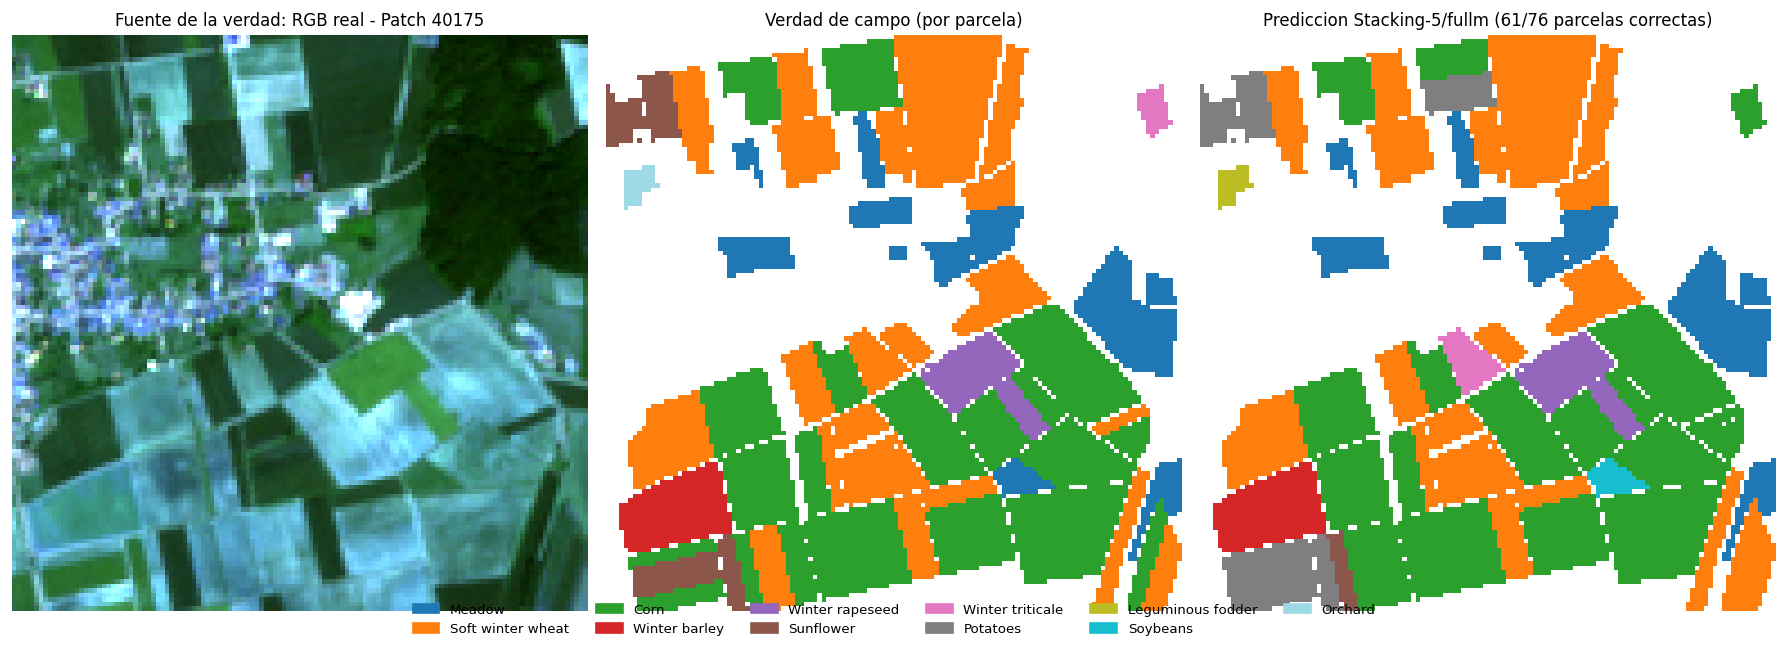

**Fenologia que apoya cada prediccion** (curva NDVI por parcela, fuera de la imagen):

- **40175_7235574** -> predice **Meadow** (real: Meadow, acierto, pico NDVI 0.786): pico de vigor alto (NDVI 0.79) a media temporada; dinamica estacional marcada (amplitud 0.80)
- **40175_7234054** -> predice **Winter barley** (real: Winter barley, acierto, pico NDVI 0.92): pico de vigor alto (NDVI 0.92) a media temporada; dinamica estacional marcada (amplitud 0.95)
- **40175_7275069** -> predice **Corn** (real: Corn, acierto, pico NDVI 0.915): pico de vigor alto (NDVI 0.91) tardio; dinamica estacional marcada (amplitud 0.94)
- **40175_7235571** -> predice **Corn** (real: Corn, acierto, pico NDVI 0.86): pico de vigor alto (NDVI 0.86) tardio; dinamica estacional marcada (amplitud 0.90)
- **40175_15901758** -> predice **Soft winter wheat** (real: Soft winter wheat, acierto, pico NDVI 1.803): pico de vigor alto (NDVI 1.80) tardio; dinamica estacional marcada (amplitud 1.80)
- **40175_15893644** -> predice **Corn** (real: Corn, acierto, pico NDVI 0.914): pico de vigor alto (NDVI 0.91) tardio; dinamica estacional marcada (amplitud 0.94)

In [5]:
from pathlib import Path
import numpy as np
import polars as pl
from ml.report.ensemble_inference_cards import build_stacking_inference_cards
from scripts.run_us040_ensembles import (
    _fold5_patch_ids, build_parcel_ground_truth, build_parcel_geometries, _geoms_for_blending,
)

pastis_root = REPO / 'data/PASTIS-R'
oof_dir = REPO / 'ml/eval/oof'
patches_ng = ['40039', '40005', '40175']  # 3 escenas diversas (8-9 cultivos) por ensamble no-ganador


def _pred_by_parcel(proba, keys):
    """Map an ensemble's per-parcel argmax to {canonical_parcel_id: PASTIS class id}."""
    cls = proba.argmax(axis=1) + 1  # contiguo 0..17 -> PASTIS 1..18
    return dict(zip(keys, [int(c) for c in cls]))


if pastis_root.exists():
    from ml.ensemble.stacking import StackingEnsemble
    from ml.ensemble.blending import BlendingEnsemble

    pids_all = _fold5_patch_ids(oof_dir)
    gt = build_parcel_ground_truth(pids_all, pastis_root)
    geoms = build_parcel_geometries(pids_all, pastis_root)

    # Blending-3 (subcampeon): pesos convexos Optuna sobre los 3 miembros base.
    bl = BlendingEnsemble(('tsvit-pheno', 'utae', 'xgb-alphaearth'),
                          n_trials=50, oof_dir=oof_dir, random_state=42).fit(
        _geoms_for_blending(geoms), y_true=gt)
    bl_pred = _pred_by_parcel(bl.predict_proba(), list(bl._member_ids))

    # Stacking-5/fullm (mejor individual pero apila peor).
    st = StackingEnsemble(
        base_members=('tsvit-pheno-fullm', 'utae', 'xgb-alphaearth', 'farslip-ft18', 'farslip-zeroshot'),
        meta='logreg', n_spatial_folds=5, oof_dir=oof_dir, random_state=42).fit(geoms, gt_labels=gt)
    st_keys, _, _ = st.build_meta_features(gt_labels=None)
    st_pred = _pred_by_parcel(st.predict_proba(), st_keys['canonical_parcel_id'].to_list())

    losers = [
        ('Blending-3 (subcampeon)', ('tsvit-pheno', 'utae', 'xgb-alphaearth'), bl_pred),
        ('Stacking-5/fullm', ('tsvit-pheno-fullm', 'utae', 'xgb-alphaearth', 'farslip-ft18', 'farslip-zeroshot'), st_pred),
    ]
    for label, members, pred in losers:
        cards = build_stacking_inference_cards(
            patches_ng, pastis_root=pastis_root, oof_dir=oof_dir,
            features_path=REPO / 'data/features/features_fused_pastis.parquet',
            out_dir=REPO / 'reports/ensemble/figures/inference',
            members=members, ensemble_label=label, pred_by_parcel=pred)
        for card in cards:
            acc = 100 * card.n_correct / max(card.n_parcels, 1)
            display(Markdown(f'#### {label} -- Patch {card.patch_id}: '
                             f'**{card.n_correct}/{card.n_parcels}** parcelas correctas ({acc:.0f}%)'))
            show_saved_png(card.figure_path,
                caption=f'{label}: izq RGB real | centro verdad | der prediccion. '
                        'La fenologia va como texto debajo, no sobre la imagen.')
            display(_fenologia_markdown(card))
else:
    display(Markdown('> PASTIS-R no presente: las fichas de los no-ganadores se '
        'generan al re-ejecutar donde este el dataset.'))


## Figuras interpretadas del ensamble elegido (Stacking)

Generadas en US-040 y versionadas. No basta con mostrarlas: cada figura responde una pregunta distinta sobre el modelo. Se interpretan una a una.

**Matriz de confusion del Stacking: normalizada por recall (izq) y en conteos absolutos (der).**

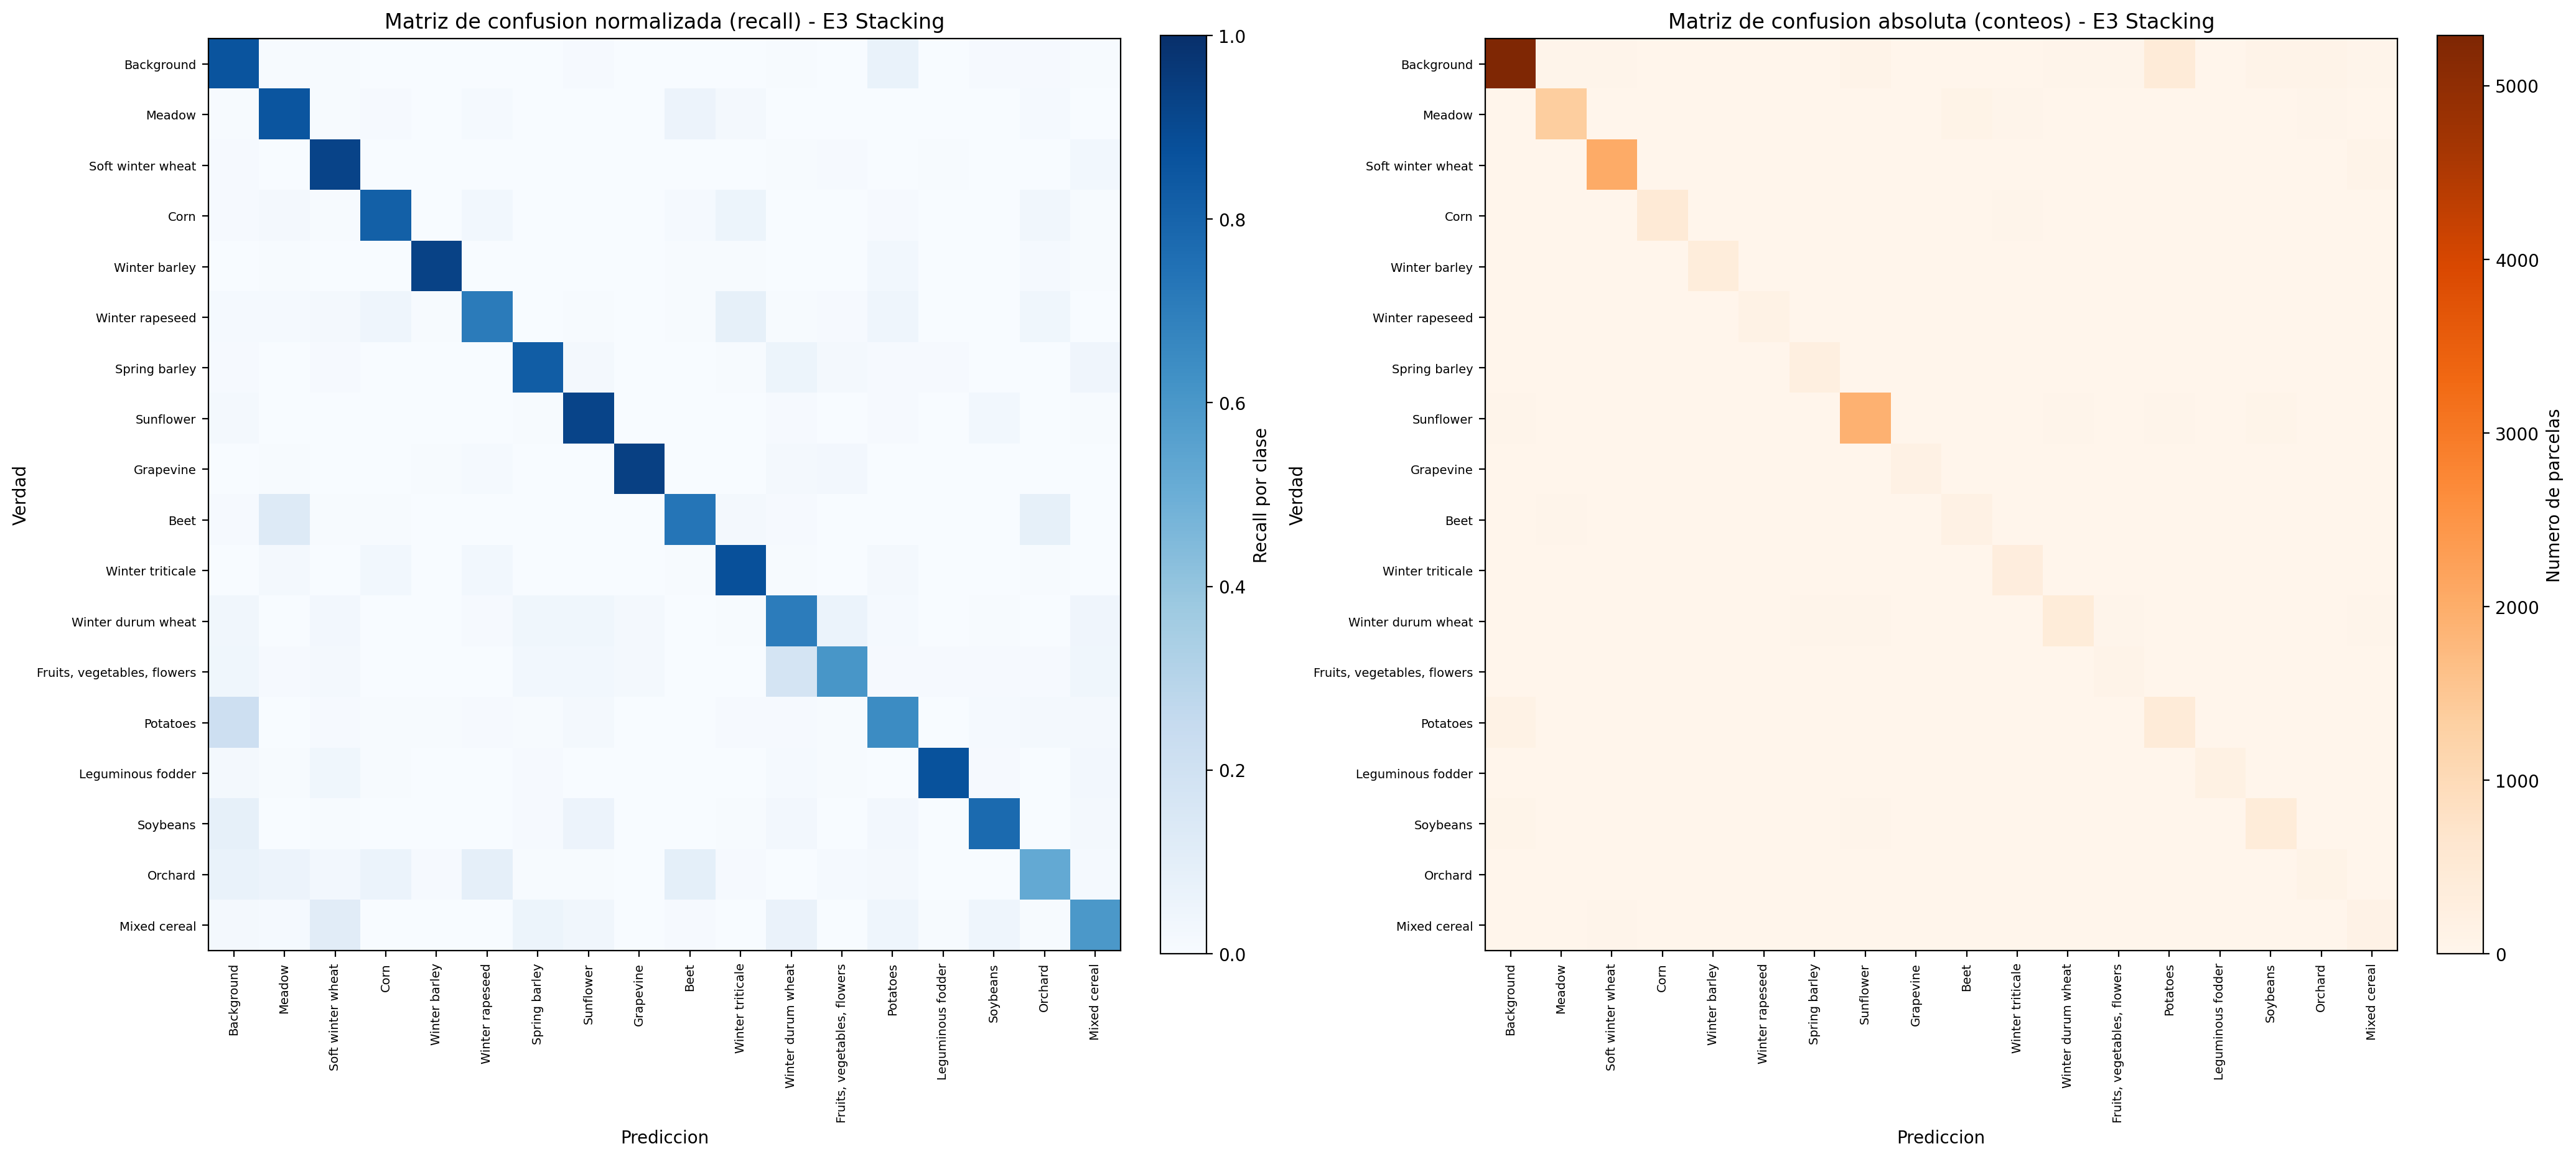

In [6]:
show_saved_png(REPO / 'reports/ensemble/figures/'
               'confusion_stacking.png', caption='Matriz de confusion del Stacking: normalizada por recall (izq) y en conteos absolutos (der).')

### Como leer la matriz de confusion

Son dos vistas del mismo resultado. La **izquierda (normalizada por recall)** responde *de cada clase real, que fraccion acerto el modelo*: la diagonal intensa indica que la mayoria de clases se predicen bien (diagonal fuerte = pocos errores). La **derecha (conteos absolutos)** revela el **desbalance brutal** del dataset: `Background` (~5,000+ parcelas) y `Sunflower` (~3,000) dominan, mientras clases como `Orchard` o `Mixed cereal` apenas tienen muestras.

Lo que hay que leer juntando ambas: el modelo casi no se equivoca **entre clases muy distintas**; los errores se concentran en **confusiones agronomicamente plausibles** -- cereales de invierno entre si (triticale / trigo duro / cebada), y los cultivos raros de pocas muestras que se diluyen hacia las clases dominantes. No es ruido aleatorio: es ambiguedad real + falta de ejemplos.

**Curva ROC una-vs-resto por clase (macro-AUC 0.976).**

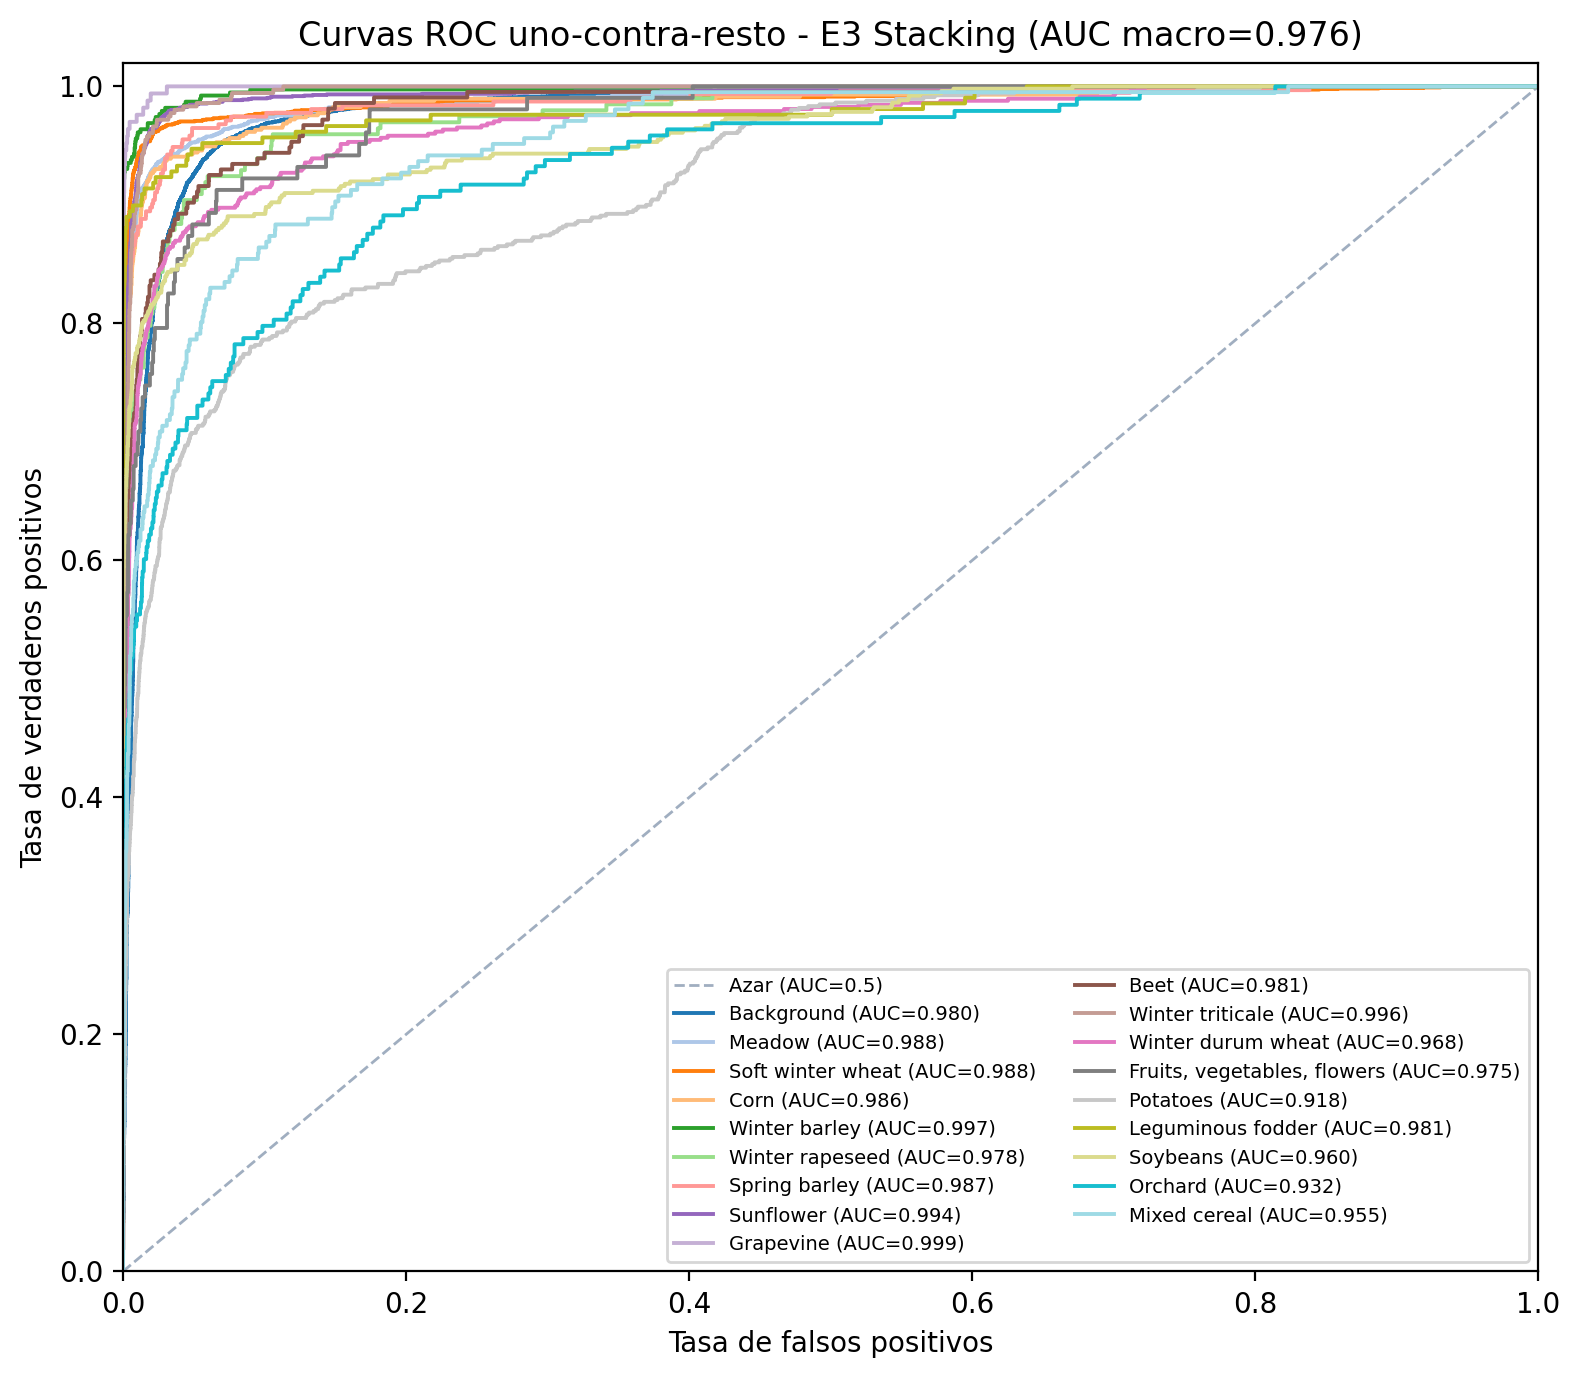

In [7]:
show_saved_png(REPO / 'reports/ensemble/figures/'
               'roc_ovr_stacking.png', caption='Curva ROC una-vs-resto por clase (macro-AUC 0.976).')

### Como leer la ROC una-vs-resto (macro-AUC 0.976)

Para cada clase se trata el problema como 'esta clase vs todas las demas' y se mide el area bajo la curva ROC (AUC): 1.0 = separacion perfecta, 0.5 = azar. El **macro-AUC 0.976** (promedio sobre las 18 clases) dice que el Stacking **ordena muy bien** las probabilidades: si tomas una parcela positiva y una negativa al azar, casi siempre le da mas probabilidad a la positiva.

**Cuidado con sobre-leer la ROC:** el AUC es optimista bajo desbalance (los muchos negativos faciles inflan la curva). Por eso miramos tambien la precision-recall (siguiente figura), que es la metrica honesta cuando la clase positiva es minoritaria.

**Curvas precision-exhaustividad por clase (AP macro 0.795).**

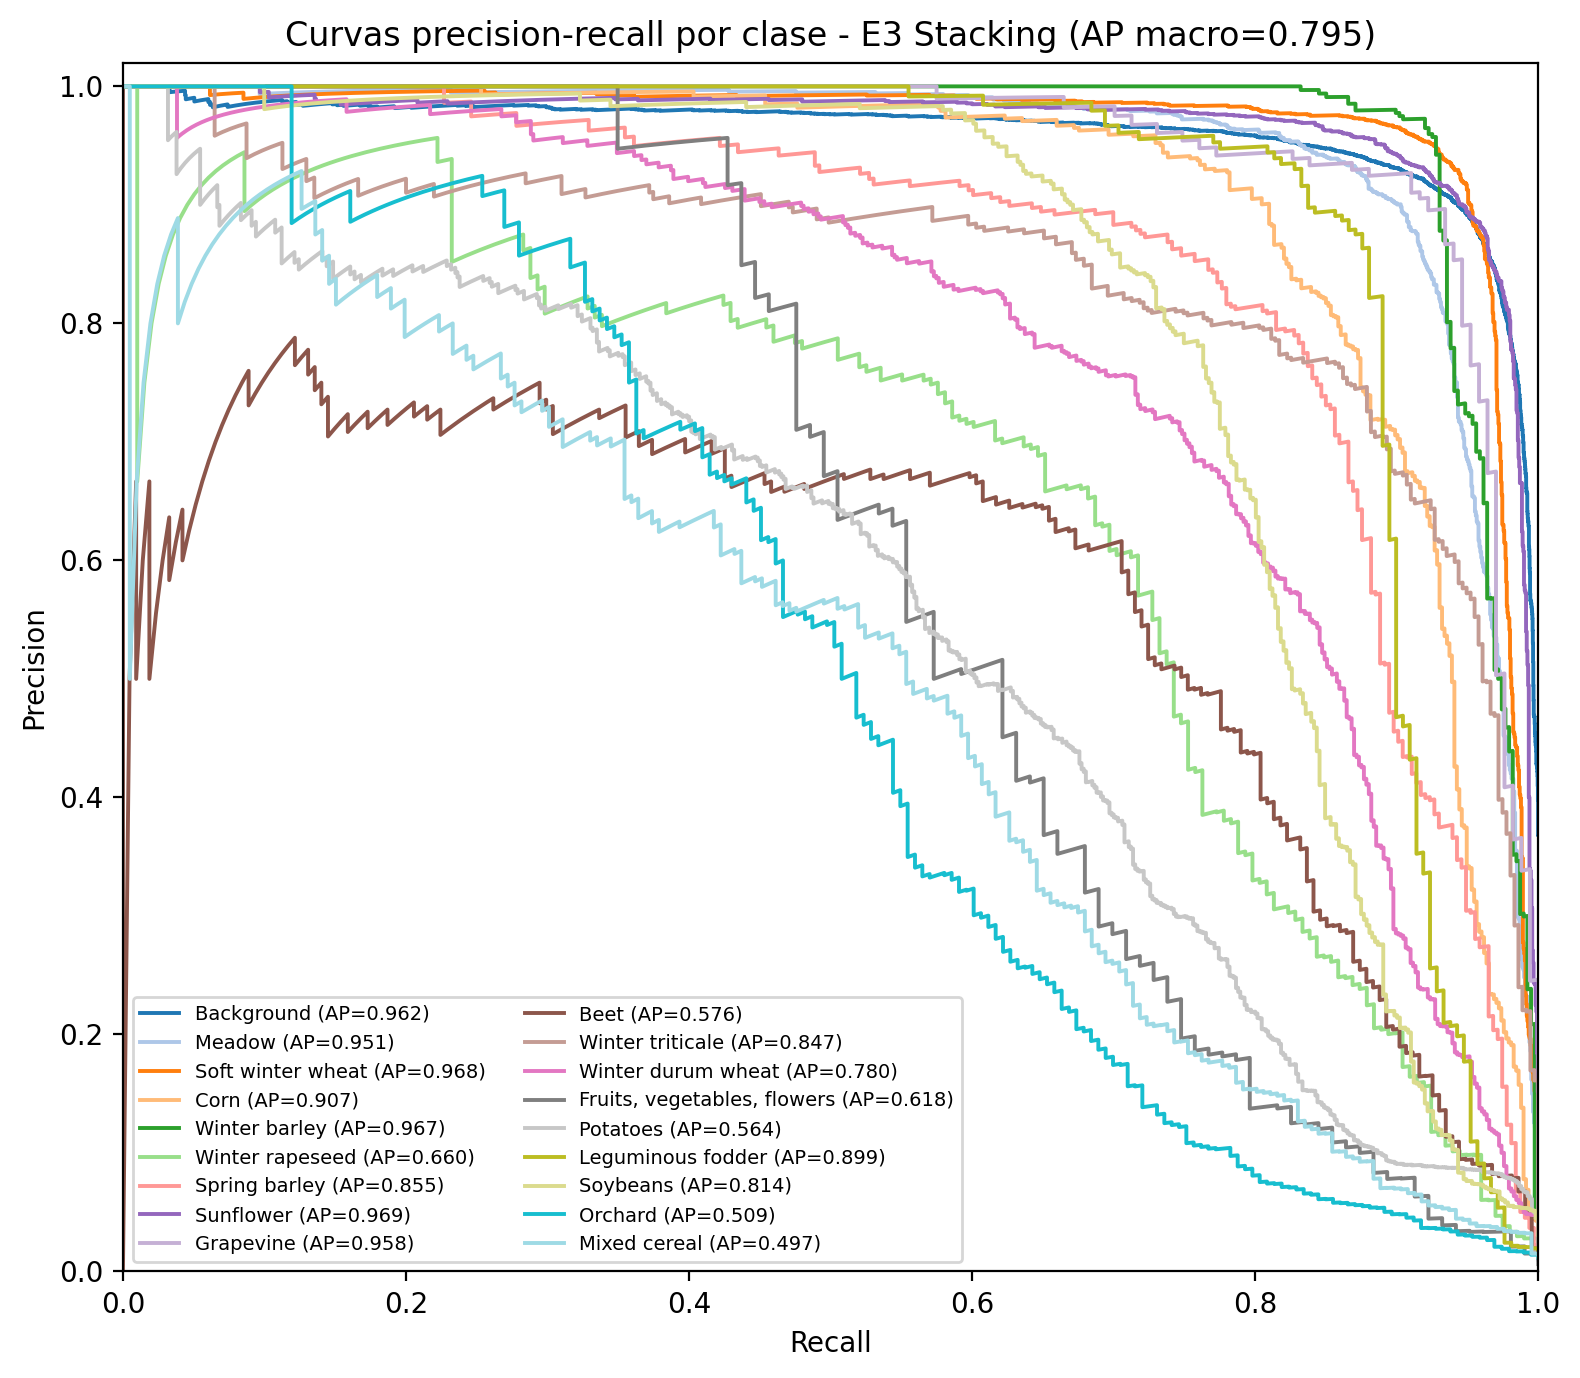

In [8]:
show_saved_png(REPO / 'reports/ensemble/figures/'
               'pr_stacking.png', caption='Curvas precision-exhaustividad por clase (AP macro 0.795).')

### Como leer la precision-recall por clase (AP macro 0.795)

Esta es **la figura mas informativa** bajo desbalance. Cada curva es una clase; el area bajo ella (AP, Average Precision) resume su calidad. Una curva alta y plana = el modelo mantiene precision aun subiendo el recall. El **AP macro 0.795** es mas bajo que el AUC 0.976 precisamente porque la PR no se deja enganar por los negativos faciles -- **0.795 es la cifra realista** del poder del modelo.

Leyendo los AP de la leyenda, hay **tres grupos claros**:

| Grupo | Clases (AP) | Por que |
|---|---|---|
| **Fuertes (>0.90)** | Sunflower 0.97, Soft winter wheat 0.97, Winter barley 0.97, Background 0.96, Grapevine 0.96, Meadow 0.95, Corn 0.91 | firma temporal/espectral marcada + muchas muestras |
| **Intermedias (0.78-0.90)** | Leguminous fodder 0.90, Spring barley 0.86, Winter triticale 0.85, Soybeans 0.81, Winter durum wheat 0.78 | senal decente pero se confunden con parientes cercanos |
| **Debiles (<0.66)** | Winter rapeseed 0.66, Fruits/veg/flowers 0.62, Beet 0.58, Potatoes 0.56, Orchard 0.51, Mixed cereal 0.50 | pocas muestras + fenologia ambigua o heterogenea |

El patron es nitido: **el modelo brilla donde hay senal clara y muchos datos, y sufre en las clases raras o de fenologia ambigua**. Esto coincide exactamente con lo que la matriz de confusion mostraba.

**Residuos espaciales del Blending sobre el fold-5 (acierto 0.860).**

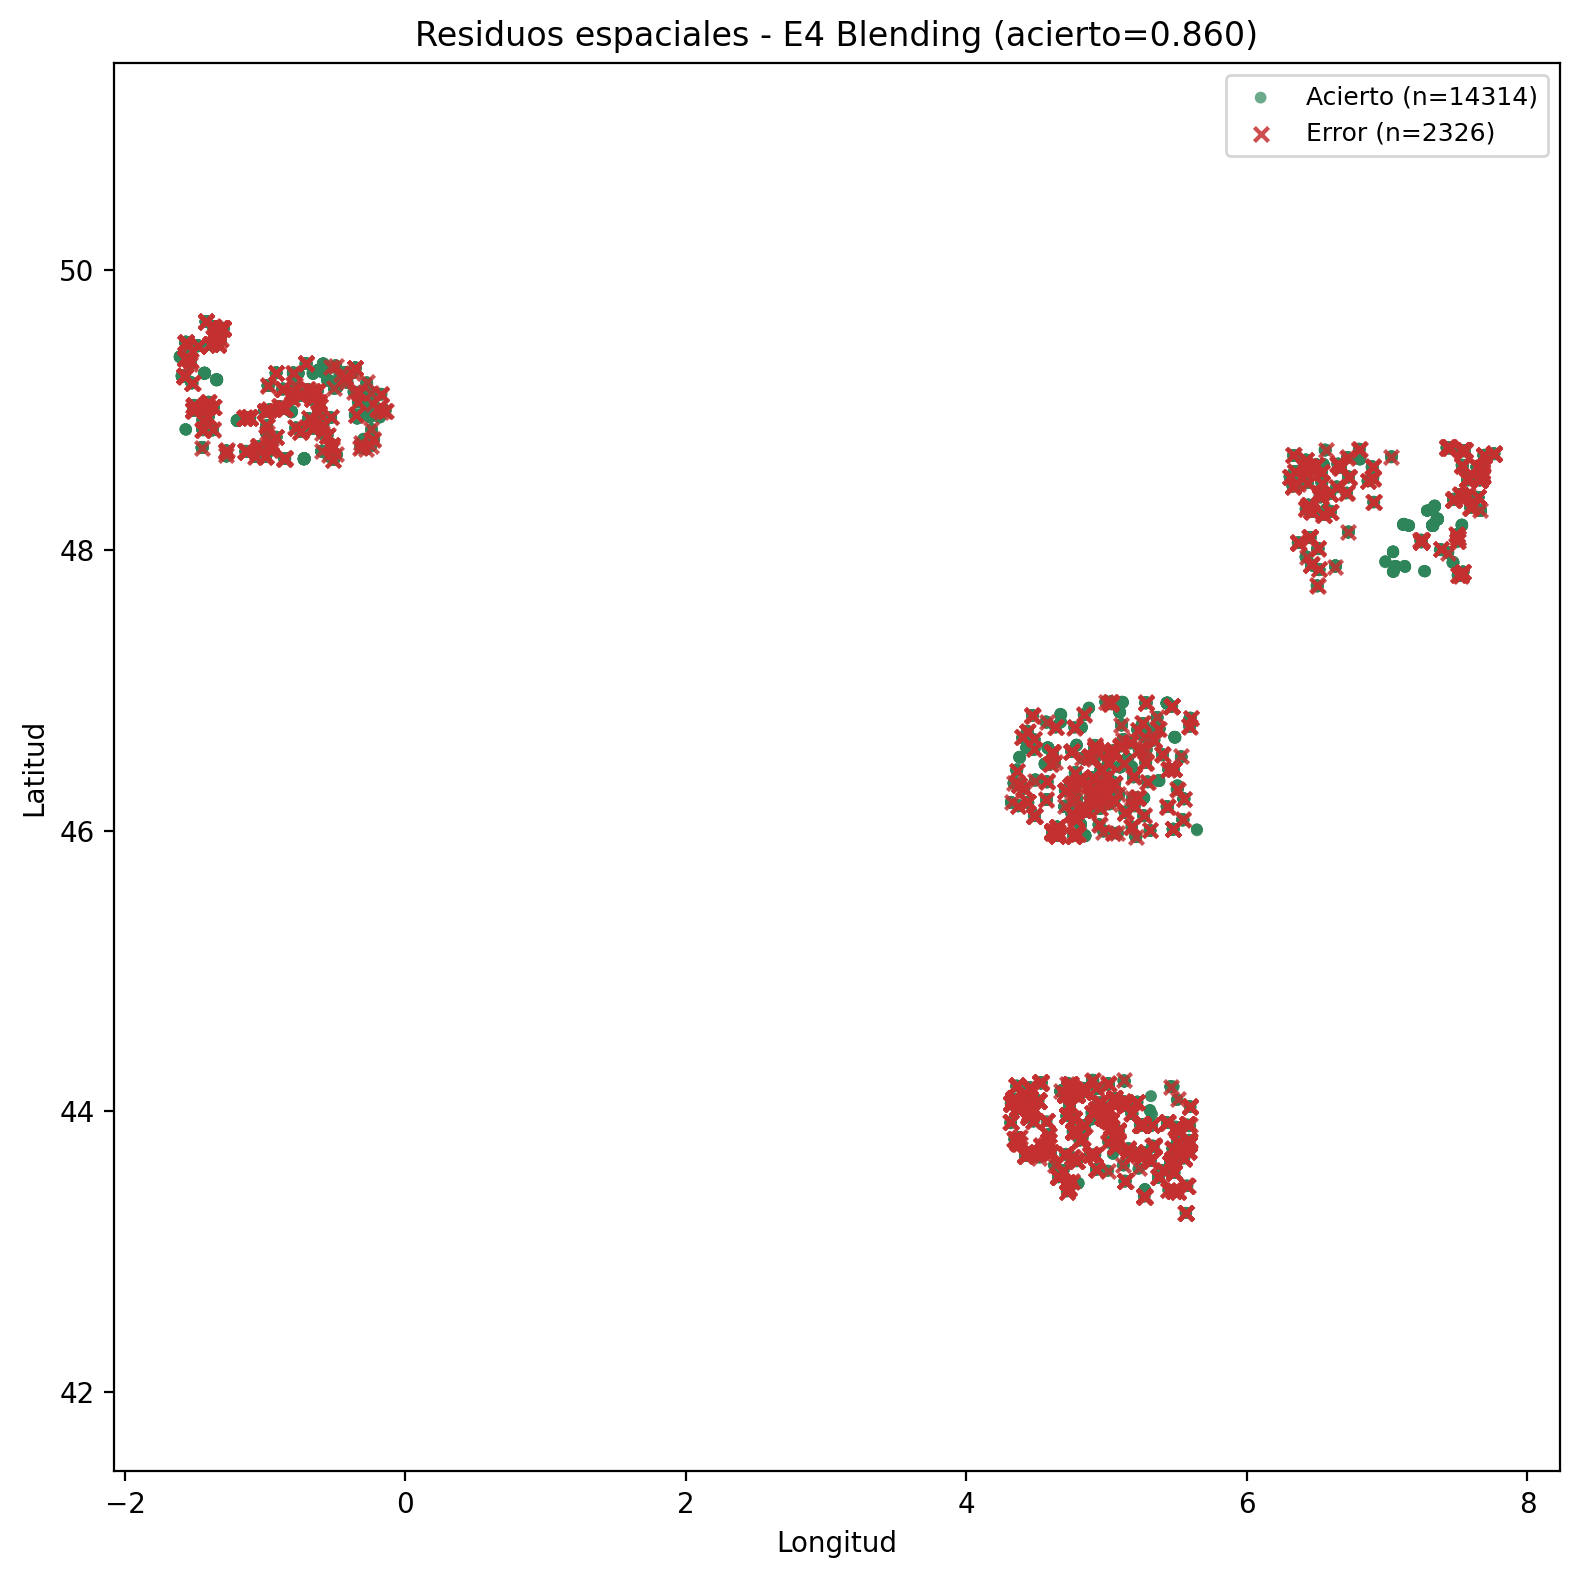

In [9]:
show_saved_png(REPO / 'reports/ensemble/figures/'
               'spatial_residuals_blending.png', caption='Residuos espaciales del Blending sobre el fold-5 (acierto 0.860).')

### Como leer los residuos espaciales (donde falla geograficamente)

Cada punto es una parcela del fold-5 ubicada por su coordenada: verde = acierto, roja = error. Los **cuatro cumulos** son las regiones geograficas de PASTIS (los folds estan separados espacialmente, por eso se agrupan). La pregunta clave: **hay alguna region sistematicamente peor?**

La respuesta es **no**: los errores (rojo) estan repartidos dentro de cada cumulo, sin una zona que sea toda roja. Es decir, **el error es por CLASE, no por GEOGRAFIA**. Esto es una buena noticia metodologica: confirma que el anti-fuga espacial funciono (el modelo no memorizo una region) y que para mejorar hay que atacar **las clases dificiles**, no recolectar datos de una zona concreta.

## US-041 -- Ensamble E-a: fusion dual-head TSViT-pheno + FarSLIP por-parcela

Tras descubrir que el **FarSLIP por-parcela** rompe el techo de las 4 clases (ver notebook 06b: macro-F1 0.70 vs 0.16 del FarSLIP por-patch), la pregunta natural es: **suma combinarlo con el mejor segmentador?**

La fusion *dual-head* mezcla las probabilidades de los dos cabezales con un peso aprendido `alpha`:

```
P_fused = alpha * P_tsvit + (1 - alpha) * P_farslip
```

- `P_tsvit`: probabilidades por parcela del TSViT-pheno (el mejor segmentador denso, reducido a parcela).
- `P_farslip`: probabilidades por parcela del FarSLIP por-parcela, obtenidas por **similitud coseno** del embedding CLS-768 de cada parcela contra el banco de prototipos visuales por clase.
- `alpha` se busca por *grid-search* sobre **sub-folds espaciales del fold-5** (anti-fuga), no a ojo.

Expectativa honesta declarada de antemano (R-HONEST-GAIN): como el TSViT ya es muy fuerte, la ganancia esperada de E-a es **pequena** (`alpha` alto), no espectacular. El valor cientifico es **medir** si el FarSLIP por-parcela aporta senal complementaria, no asumirlo.

In [10]:
# US-041 E-a: metricas reales (fusion dual-head TSViT-pheno + FarSLIP por-parcela).
import polars as pl

results_csv = REPO / 'reports/ensemble/metrics/us041_042_ea_eb_results.csv'
if results_csv.is_file():
    res = pl.read_csv(results_csv, infer_schema_length=None)
    ea = res.filter(pl.col('modelo').str.contains('E-a') | pl.col('modelo').str.contains('individual'))
    display(Markdown('**Resultado real E-a (fold-5):** la fusion ingenua 4-vs-18 clases DANA al TSViT.'))
    display(ea.with_columns(pl.col('f1_macro').round(4)))
    display(Markdown(
        'La fusion por `alpha` global mezcla un FarSLIP de 4 clases con un TSViT de 18: '
        'arrastra el F1 de 0.6764 a **0.2694** (gain -0.407). La leccion que abre US-043: '
        'FarSLIP no entra por fusion global, sino por **stacking** (pesos por clase).'))
else:
    display(Markdown('> **E-a pendiente.** `run_us041_ea.py` re-vuelca la OOF del '
        'TSViT-pheno, construye los prototipos visuales del FarSLIP por-parcela, '
        'ajusta `alpha` sobre sub-folds del fold-5 y evalua contra el TSViT solo.'))


**Resultado real E-a (fold-5):** la fusion ingenua 4-vs-18 clases DANA al TSViT.

modelo,f1_macro,accuracy,nota
str,f64,f64,str
"""TSViT-pheno-fullm (individual)""",0.6764,null,"""mejor segmentador individual (…"
"""E-a fusion dual-head (alpha=0.…",0.2694,0.5873,"""gain -0.407 vs TSViT: fusion i…"
"""E-b stacking E-a + AlphaEarth""",0.3395,0.6937,"""gain +0.156 vs E-a sola pero l…"


La fusion por `alpha` global mezcla un FarSLIP de 4 clases con un TSViT de 18: arrastra el F1 de 0.6764 a **0.2694** (gain -0.407). La leccion que abre US-043: FarSLIP no entra por fusion global, sino por **stacking** (pesos por clase).

## US-042 -- Ensamble E-b: stacking E-a + AlphaEarth multi-anual

E-b extiende el stacking ganador anadiendo un base learner mas: **AlphaEarth promediado en varios anos** (2018 + 2019). La hipotesis es que promediar el embedding anual reduce el ruido de un ano puntual (nubes, fenologia atipica) y aporta una vista mas estable de cada parcela.

El stacking es **generico en sus miembros**: anadir AlphaEarth multi-anual no cambia la arquitectura, solo agrega su matriz OOF `(n_parcelas, 18)` a las meta-features. El meta-modelo decide si ese nuevo miembro merece peso.

Caveat honesto declarado de antemano: el AlphaEarth tabular **satura** en 18 clases (XGBoost-AlphaEarth ~0.44 de F1-macro), asi que **E-b podria NO superar a E-a** -- y eso seria un resultado valido, no un fracaso. Se reporta lo que de la evidencia.

In [11]:
# US-042 E-b: metricas reales (stacking E-a + AlphaEarth multi-anual).
import polars as pl

results_csv = REPO / 'reports/ensemble/metrics/us041_042_ea_eb_results.csv'
if results_csv.is_file():
    res = pl.read_csv(results_csv, infer_schema_length=None)
    eb = res.filter(pl.col('modelo').str.contains('E-a') | pl.col('modelo').str.contains('E-b'))
    display(Markdown('**Resultado real E-b (fold-5) vs E-a:**'))
    display(eb.with_columns(pl.col('f1_macro').round(4)))
    display(Markdown(
        'Meter AlphaEarth multi-anual al stacking recupera a E-a (0.2694 -> **0.3395**, '
        'gain +0.156) pero sigue lejos del Stacking US-040 (0.747): partir de una E-a '
        'rota no se arregla apilando. El camino bueno es US-043 (FarSLIP directo al '
        'mejor ensamble), no remendar la fusion E-a.'))
else:
    display(Markdown('> **E-b pendiente.** `run_us042_eb.py` construye el AlphaEarth '
        'promediado 2018-2019, materializa su OOF y lo agrega como base learner al '
        'stacking `(ea-fusion, xgb-alphaearth)`, comparando contra E-a sola.'))


**Resultado real E-b (fold-5) vs E-a:**

modelo,f1_macro,accuracy,nota
str,f64,f64,str
"""E-a fusion dual-head (alpha=0.…",0.2694,0.5873,"""gain -0.407 vs TSViT: fusion i…"
"""E-b stacking E-a + AlphaEarth""",0.3395,0.6937,"""gain +0.156 vs E-a sola pero l…"


Meter AlphaEarth multi-anual al stacking recupera a E-a (0.2694 -> **0.3395**, gain +0.156) pero sigue lejos del Stacking US-040 (0.747): partir de una E-a rota no se arregla apilando. El camino bueno es US-043 (FarSLIP directo al mejor ensamble), no remendar la fusion E-a.

## US-043 -- La capa FarSLIP sobre el mejor ensamble

El sponsor pidio meter FarSLIP a **nuestro mejor ensamble** en sus dos variantes y dejar que el LLM (Gemma 4 local) genere las descripciones fenologicas:

- **`farslip-ft18`**: la torre de vision de FarSLIP fine-tuneada, puntuada por coseno contra 18 prototipos visuales (CLS medio por clase en folds 1-4) y softmax por parcela. El student nunca ve fold-5 (prototipos de 1-4, prediccion en 5) -> OOF sin fuga.
- **`farslip-zeroshot`**: la **misma torre de vision** de FarSLIP + la torre de **texto CLIP base** (el extractor solo carga el `vision_model`; `text_model`/`text_projection` quedan en CLIP base). Cada parcela se puntua por coseno contra los 18 prompts de clase con temperatura FIJA (a priori, nunca ajustada contra fold-5, R-LEAK).

Para responder honestamente *si FarSLIP aporta*, se prueba sobre **dos bases de TSViT** -- el `tsvit-pheno` que respaldo al campeon US-040 (0.747) y el `tsvit-pheno-fullm` (mejor individual) -- cruzadas con Stacking/Blending y 3-vs-5 miembros. Todo fold-5 held-out, espacio semantic18 (18 clases), mismas 16 640 parcelas.

modelo,f1_macro,accuracy,delta_farslip
str,f64,f64,f64
"""Stacking-3 | tsvit-pheno (camp…",0.747,0.849,0.0
"""Stacking-5 (+FarSLIP) | tsvit-…",0.7486,0.8495,0.0016
"""Blending-3 | tsvit-pheno (camp…",0.7436,0.8629,0.0
"""Blending-5 (+FarSLIP) | tsvit-…",0.7319,0.8594,-0.0117
"""Stacking-3 | tsvit-pheno-fullm…",0.6359,0.7877,0.0
"""Stacking-5 (+FarSLIP) | tsvit-…",0.6477,0.7935,0.0118
"""Blending-3 | tsvit-pheno-fullm…",0.5651,0.7697,0.0
"""Blending-5 (+FarSLIP) | tsvit-…",0.5866,0.7864,0.0215


**US-043: F1 macro de cada ensamble. Verde = +FarSLIP (5 miembros); gris = base (3). La linea roja es el campeon US-040 (0.747).**

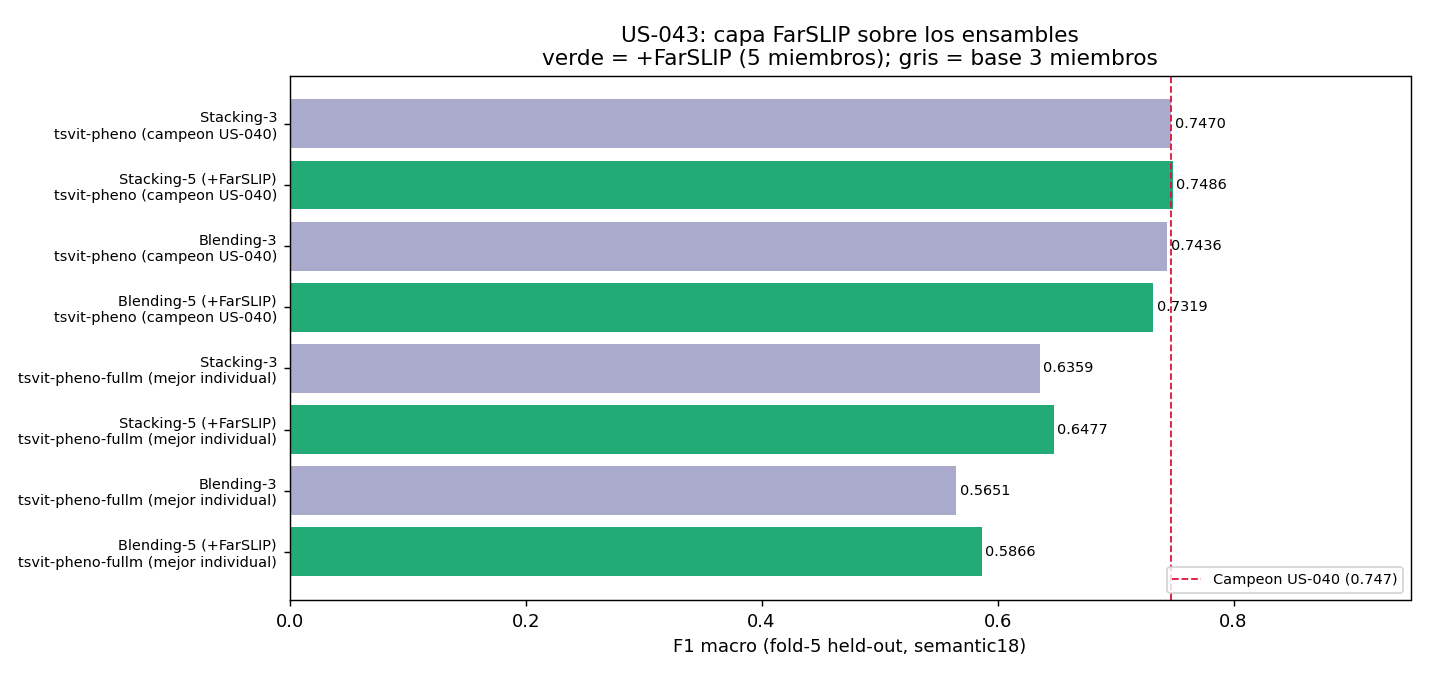

In [12]:
# US-043: grilla real (fold-5 held-out). FarSLIP x {pheno, fullm} x {Stacking, Blending} x {3, 5 miembros}.
import polars as pl

grid_csv = REPO / 'reports/ensemble/metrics/us043_farslip_grid.csv'
if grid_csv.is_file():
    g = pl.read_csv(grid_csv, infer_schema_length=None).with_columns([
        pl.col('f1_macro').round(4), pl.col('accuracy').round(4), pl.col('delta_farslip').round(4),
    ])
    display(g)
else:
    display(Markdown('> Grilla no encontrada (la genera `run_us043_farslip_ensembles`).'))

show_saved_png(REPO / 'reports/ensemble/figures/us043_farslip/grid_farslip_5_vs_3.png',
               caption='US-043: F1 macro de cada ensamble. Verde = +FarSLIP (5 miembros); gris = base (3). La linea roja es el campeon US-040 (0.747).')

**Como leer la grilla (interpretacion honesta):**

- **Nuevo campeon: Stacking-5 sobre `tsvit-pheno` = 0.7486** (acc 0.849), un **+0.0016** sobre el Stacking-3 campeon (0.747). FarSLIP aporta poco pero el meta-logreg le asigna pesos no triviales -> no lo descarta, suma una pizca de senal complementaria.
- **El blending SI se degrada con FarSLIP** sobre la base campeona (0.744 -> 0.732, **-0.0117**). El blending pondera con un `alpha` global; al meter dos miembros mas debiles arrastra el promedio. El **stacking es estructuralmente mas seguro**: el meta-modelo aprende pesos por clase y "apaga" a FarSLIP donde no ayuda.
- **Hallazgo contraintuitivo clave:** `tsvit-pheno-fullm` es **mejor individual** (0.6764 vs 0.6253 del `tsvit-pheno`) pero **apila peor** (stacking 0.636 vs 0.747). La ganancia de un ensamble viene de la **complementariedad**, no de la fuerza individual: `fullm` esta mas correlacionado con U-TAE y XGB, asi que aporta menos diversidad. Por eso el mejor ensamble sigue usando el `tsvit-pheno` "viejo".
- En la base `fullm`, FarSLIP **si** ayuda mas (stacking +0.0118, blending +0.0215), porque parte de un piso mas bajo con mas hueco que llenar.

**F1 por clase del ensamble ganador. Verde oscuro F1>=0.90; verde claro 0.72-0.90; rojo <0.72 (candidatas a descartar).**

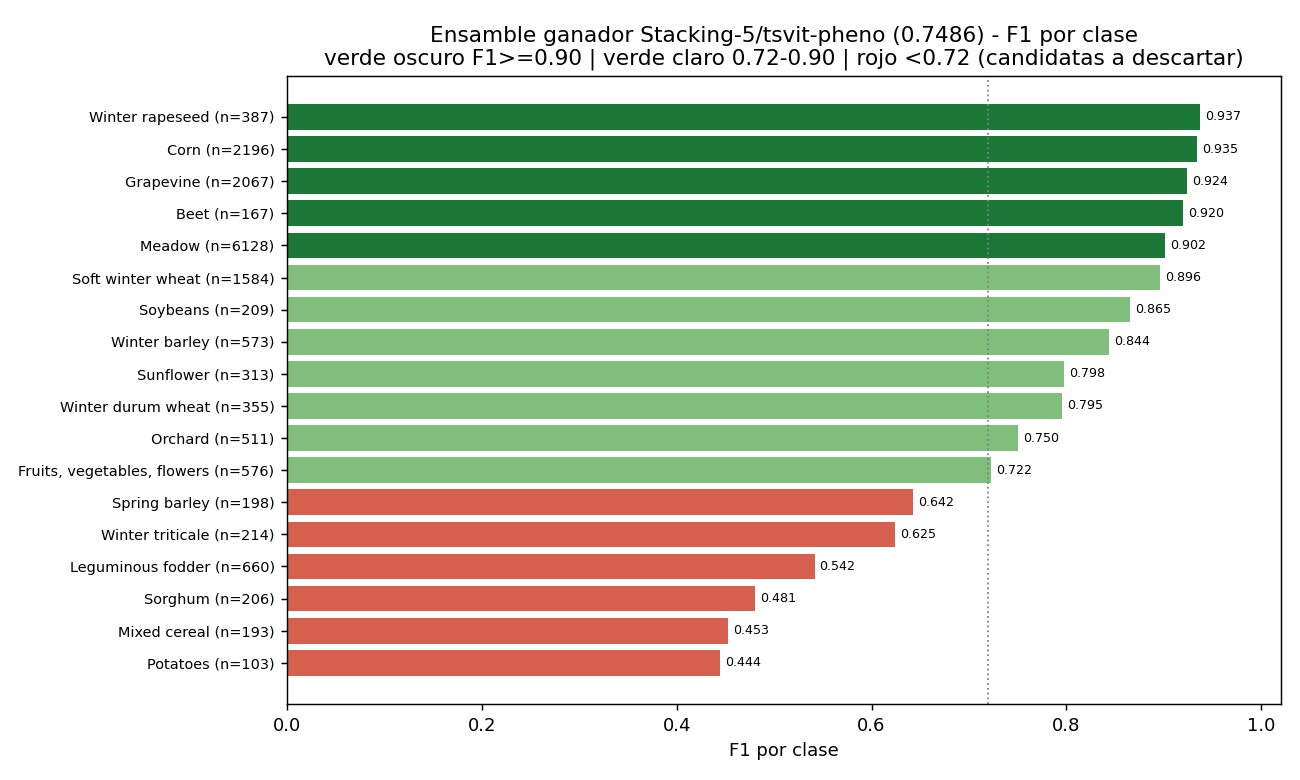

**Curva de cardinalidad top-K: macro-F1 sobre las K clases mejor resueltas (verde) vs fraccion de parcelas cubierta (azul).**

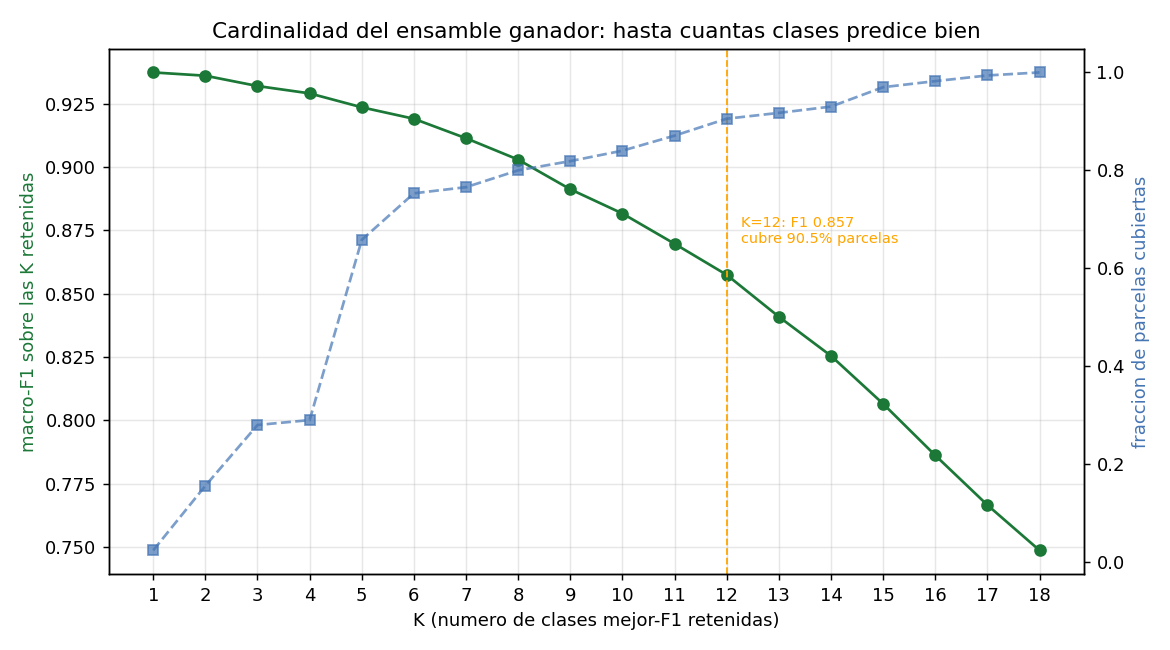

k,macro_f1_topk,cumulative_support_share
i64,f64,f64
1,0.9373,0.0233
2,0.936,0.1552
3,0.932,0.2794
4,0.9291,0.2895
5,0.9236,0.6578
…,…,…
14,0.8254,0.9302
15,0.8065,0.9698
16,0.7861,0.9822


In [13]:
# US-043: cardinalidad del ensamble GANADOR (Stacking-5/tsvit-pheno, 0.7486) -- hasta cuantas clases predice bien.
import polars as pl

show_saved_png(REPO / 'reports/ensemble/figures/us043_farslip/winner_per_class_f1.png',
               caption='F1 por clase del ensamble ganador. Verde oscuro F1>=0.90; verde claro 0.72-0.90; rojo <0.72 (candidatas a descartar).')
show_saved_png(REPO / 'reports/ensemble/figures/us043_farslip/winner_cardinality_curve.png',
               caption='Curva de cardinalidad top-K: macro-F1 sobre las K clases mejor resueltas (verde) vs fraccion de parcelas cubierta (azul).')

curve_csv = REPO / 'reports/ensemble/metrics/us043_winner_cardinality_curve.csv'
if curve_csv.is_file():
    cur = pl.read_csv(curve_csv, infer_schema_length=None).with_columns([
        pl.col('macro_f1_topk').round(4), pl.col('cumulative_support_share').round(4),
    ])
    display(cur)

**Cardinalidad: hasta cuantas clases predice bien el ensamble.**

La curva top-K retiene las K clases con mejor F1 y promedia su F1. El "codo" responde la pregunta del sponsor:

- El ensamble resuelve **muy bien ~8 clases** (macro-F1 0.903, cubren el 80% de las parcelas) y **bien hasta ~12** (macro-F1 0.857, 90.5% de las parcelas). Con F1>=0.90 estan rapeseed de invierno, maiz, vid, remolacha y prado.
- Las **6 clases mas debiles** (F1 < 0.65, todas de bajo soporte: 103-660 parcelas) son **cebada de primavera (0.642), triticale de invierno (0.625), forraje leguminoso (0.542), sorgo (0.481), cereal mixto (0.453) y patata (0.444)**. Arrastran el macro-F1 global de 0.857 (K=12) a 0.749 (K=18).
- **Descartar esas 6** subiria el macro-F1 a **0.857** cubriendo aun el **90.5%** de las parcelas reales: el 9.5% restante son justamente las clases raras y fenologicamente ambiguas (cereales de invierno que se confunden entre si).

> R-LEAK: este reporte por clase es el descriptivo **final** sobre fold-5. Un descarte real para reentrenar debe **decidirse** sobre los sub-folds OOF (folds 1-4), nunca sobre fold-5, para no hacer cherry-picking contra la misma particion que se reporta.

### Descarte HONESTO de clases: re-evaluar con 16, 14, 12... 8 clases

La curva top-K de arriba es *descriptiva* (promedia el F1 de las K mejores clases sobre fold-5). Aqui respondemos la pregunta de verdad -- **"si el ensamble solo tuviera que clasificar K clases, descartando las peores de 2 en 2, que F1-macro real da?"** -- y lo hacemos **sin trampa** (regla anti-fuga R-LEAK):

- **El orden de descarte se DECIDE en las predicciones OOF** (cada parcela predicha por un meta-modelo de stacking que NO la vio, vía los sub-folds espaciales). fold-5 nunca decide que clase se quita.
- **La metrica se MIDE en fold-5** una sola vez, con ese orden congelado: para cada K se recalcula el F1-macro sobre las parcelas cuya etiqueta real es una clase retenida (las parcelas de clases descartadas salen de la tarea, no se re-etiquetan).

Seria trampa probar los subconjuntos en fold-5 y quedarse con el mejor; aqui el split que decide y el que mide estan separados.

k,macro_f1_fold5,accuracy_fold5,n_parcels_fold5,dropped_names
i64,f64,f64,i64,str
18,0.7486,0.8495,16640,""""""
16,0.771,0.8524,16092,"""Winter durum wheat; Mixed cere…"
14,0.8194,0.8571,15783,"""Sorghum; Potatoes; Winter duru…"
12,0.8573,0.8677,14925,"""Leguminous fodder; Spring barl…"
10,0.8905,0.8728,14200,"""Orchard; Winter triticale; Leg…"
8,0.9201,0.8811,13311,"""Sunflower; Fruits, vegetables,…"


**Descarte honesto: F1-macro real en fold-5 al retener K clases (orden de descarte decidido en OOF). Barras = % de parcelas que cubren esas K clases.**

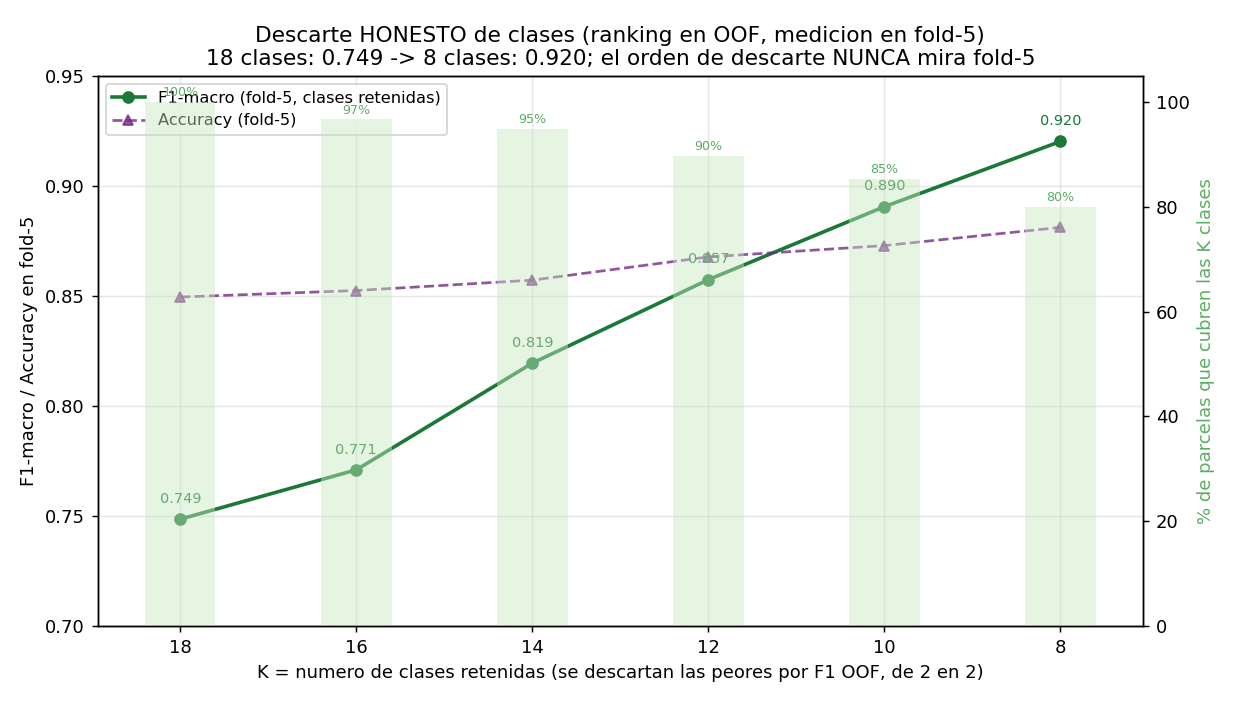

In [14]:
# US-043: curva de descarte HONESTO (rank en OOF, mide en fold-5). K = 18,16,...,8.
import polars as pl

dropout_csv = REPO / 'reports/ensemble/metrics/us043_honest_dropout_curve.csv'
if dropout_csv.is_file():
    d = pl.read_csv(dropout_csv, infer_schema_length=None).with_columns([
        pl.col('macro_f1_fold5').round(4), pl.col('accuracy_fold5').round(4),
    ])
    display(d.select('k','macro_f1_fold5','accuracy_fold5','n_parcels_fold5','dropped_names'))
else:
    display(Markdown('> Curva no encontrada (la genera honest_class_dropout_curve).'))

show_saved_png(REPO / 'reports/ensemble/figures/us043_farslip/honest_class_dropout.png',
               caption='Descarte honesto: F1-macro real en fold-5 al retener K clases (orden de descarte decidido en OOF). Barras = % de parcelas que cubren esas K clases.')

**Que dice el descarte honesto:**

| K clases | F1-macro (fold-5 real) | Accuracy | % parcelas | clases que se van |
|---|---|---|---|---|
| 18 (todas) | **0.749** | 0.849 | 100% | -- |
| 16 | 0.771 | 0.852 | 96.7% | trigo duro inv., cereal mixto |
| 14 | 0.819 | 0.857 | 94.8% | + sorgo, patata |
| 12 | 0.857 | 0.868 | 89.7% | + forraje leguminoso, cebada primavera |
| 10 | 0.890 | 0.873 | 85.3% | + huerto, triticale inv. |
| **8** | **0.920** | 0.881 | 80.0% | + girasol, frutas/verduras/flores |

- **No es trampa y sube fuerte**: de 0.749 (18 clases) a **0.920 (8 clases)**, porque cada paso quita justo las clases que el modelo confunde -- y las quita un ranking que *jamas* miro fold-5.
- **El punto dulce esta en K=12**: F1-macro **0.857** cubriendo aun el **89.7% de las parcelas reales**. Quitar 6 clases raras (todas <0.65 de F1 individual) sube el macro-F1 +0.108 sacrificando solo ~10% de las parcelas.
- **Para un producto**, K=12 es defendible: clasifica bien la gran mayoria del area agricola y reporta "no clasificada" en las 6 clases minoritarias ambiguas, en vez de adivinar mal. K=8 (0.920) seria un modo "alta confianza" para los 8 cultivos dominantes.
- **El accuracy se mueve poco** (0.849 -> 0.881): las clases que se descartan son raras, asi que pesan poco en el acierto global; donde se nota es en el **macro**-F1, que trata a todas las clases por igual.

## Conclusiones accionables: que descartar y como mejorar

Juntando lo que dicen las cuatro figuras, las conclusiones para mejorar los resultados -- y, igual de importante, **lo que se descarta porque la evidencia dice que no ayudaria**:

### Lo que SE DESCARTA (probado o evidenciado que no es el camino)

- **Mas Bagging / mas bootstraps.** El Bagging fue el peor ensamble (0.586): re-muestrear un solo tipo de modelo no crea diversidad. Anadir mas bags no movera la aguja.
- **Voting uniforme.** Promediar a ciegas (0.622) arrastra a los miembros debiles y es lentisimo (~42 s, opera por pixel). El meta-modelo del stacking ya lo supera; no vale la pena insistir en pesos fijos iguales.
- **Reponderar por frecuencia (class-weights) en FarSLIP** (ver 06b): ya se probo y EMPEORO (0.164 -> 0.102). El cuello de botella no era el desbalance del loss, era el grano (1-CLS-por-patch).
- **Recolectar datos de una region concreta.** Los residuos espaciales muestran que el error no se concentra geograficamente; mas datos de una zona no arreglaria las clases debiles.
- **Optimizar la ROC/AUC.** Ya es 0.976; el margen real esta en la precision-recall de las clases minoritarias, no en el AUC agregado.

### Lo que SI se intentaria (donde esta el margen real)

1. **Atacar las 6 clases debiles** (rapeseed, fruits/veg, beet, potatoes, orchard, mixed cereal). Es donde el AP cae por debajo de 0.66 y donde el macro-F1 mas se castiga. Opciones: aumento de datos especifico para esas clases, o un cabezal especializado.
2. **Agrupar cereales de invierno** (triticale / trigo duro / cebada): se confunden entre si por fenologia casi identica. Una jerarquia de clases (primero grupo, luego sub-clase) podria recuperar precision.
3. **Sumar el FarSLIP por-parcela al stacking** (US-043): la evidencia ya esta -> el **Stacking-5 con FarSLIP (ft-18 + zero-shot) es el nuevo campeon, 0.7486** (+0.0016 sobre el 0.747). Aporta poco pero el meta-modelo no lo descarta. En **blending si dana** (-0.0117): la leccion es meterlo via stacking (pesos por clase), no via promedio global. Y ojo: el mejor TSViT individual (`fullm`) apila PEOR -- la complementariedad manda sobre la fuerza individual.
4. **Calibrar las probabilidades** (p.ej. temperature scaling) antes del meta-modelo: el stacking aprende mejor sobre probabilidades bien calibradas, sobre todo en clases raras.

En una frase: **el techo de este ensamble no esta en combinar mas modelos del mismo tipo, sino en las clases raras/ambiguas**; ahi es donde vale la pena invertir, y es exactamente lo que exploran E-a y E-b.

## Conclusion del lote

- El **mejor segmentador individual** es el TSViT Full-M (US-038).
- De los cuatro ensambles base (US-040), gana el **Stacking heterogeneo** (F1-macro **0.747**), **+12 pts** sobre el mejor individual. La leccion: **la heterogeneidad aprendida** (denso + tabular, con meta-modelo) supera al promedio simple (Voting) y al re-muestreo homogeneo (Bagging).
- El **Blending** (0.741) es practicamente igual y mucho mas rapido: alternativa valida si importa la latencia.
- **E-a (US-041)** prueba si el FarSLIP por-parcela -- que en 06b paso de 0.16 a 0.70 -- aporta senal complementaria al TSViT via fusion con `alpha` aprendido.
- **E-b (US-042)** prueba si AlphaEarth multi-anual suma al stacking.
- En clasificacion patch, el **techo real de PASTIS son ~4 clases**; el grano-parcela (06b) es lo que lo rompe.

Todo se reporto **sin sobre-afirmar**, con datos reales, anti-fuga estricto (solo fold-5, post-softmax, OOF) y las ganancias honestas (E-a puede aportar poco, E-b puede no superar a E-a -- y se dice).